# EconIQ: Food Price Forecasting

The goal of this project is to predict the food price for the following month using historical food prices, economic indicators, weather information, and commodity type.

We will compare:
- Naive forecasting
- Random Forest
- XGBoost

The dataset contains food-price observations for different commodities in Kenya.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import joblib
import json

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv(
    r"C:\Users\ADMIN\OneDrive\Desktop\capstone\EconIQ\data\raw\food_price_prediction.csv",
    parse_dates=["date", "target_date"]
)

df.head()

,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
0,2006-01-01,Beans (dry),39.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,39.00,39.00,NaN,42.0,2006-02-01
1,2006-01-01,Maize (white),23.5,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,23.50,23.50,NaN,25.0,2006-02-01
2,2006-01-01,Oil (vegetable),115.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,115.00,115.00,NaN,120.0,2006-02-01
3,2006-02-01,Beans (dry),42.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,39.0,NaN,NaN,NaN,3.0,40.50,40.50,-0.03837,47.0,2006-03-01
4,2006-02-01,Maize (white),25.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,23.5,NaN,NaN,NaN,1.5,24.25,24.25,-0.03837,24.5,2006-03-01


In [6]:
df.tail()

,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
1873,2026-07-01,Rice,118.865,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,129.820,125.0,111.52,128.0,-10.955,121.958333,118.825833,1.034965,120.000,2026-08-01
1874,2026-07-01,Salt,15.000,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,14.635,15.0,13.79,10.0,0.365,13.638333,13.795833,1.034965,15.000,2026-08-01
1875,2026-07-01,Sorghum,45.000,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,50.000,85.0,80.00,75.0,-5.000,65.000000,74.953333,1.034965,44.165,2026-08-01
1876,2026-07-01,Sugar,154.720,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,150.000,150.0,116.60,162.0,4.720,141.883333,141.458333,1.034965,157.500,2026-08-01
1877,2026-07-01,Wheat flour,91.390,5.08,6.49,9.784965,1.390702,22.239615,28.10288,17.58834,67.443042,4.551489,92.915,90.0,99.57,82.0,-1.525,94.351667,95.509167,1.034965,90.555,2026-08-01


In [7]:
print(df.shape)
print(df.info())

(1878, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878 entries, 0 to 1877
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          1878 non-null   datetime64[ns]
 1   commodity                     1878 non-null   object        
 2   food_price                    1878 non-null   float64       
 3   inflation_annual_avg          1878 non-null   float64       
 4   inflation_12m                 1878 non-null   float64       
 5   central_bank_rate             1878 non-null   float64       
 6   rainfall                      1878 non-null   float64       
 7   temperature                   1878 non-null   float64       
 8   temperature_max               1878 non-null   float64       
 9   temperature_min               1878 non-null   float64       
 10  humidity                      1878 non-null   float64       
 11  wind_speed         

In [8]:
df.describe()

,date,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
count,1878,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1856.000000,1817.000000,1740.000000,1587.000000,1856.000000,1878.000000,1878.000000,1853.000000,1878.000000,1878
mean,2020-10-15 01:43:30.862619648,1414.154036,6.333860,6.279414,9.547306,2.298719,23.951953,30.108134,19.003799,66.067181,4.223519,1397.665935,1364.743531,1321.459305,1246.917092,13.274291,1400.507248,1383.975987,0.020580,1420.179494,2020-11-14 11:35:27.795527168
min,2006-01-01 00:00:00,9.890000,3.550000,1.850000,5.750000,0.120000,21.694516,27.348452,16.916645,51.113643,3.127290,8.000000,8.000000,8.000000,8.000000,-5750.400000,9.333333,9.500000,-3.500000,9.890000,2006-02-01 00:00:00
25%,2018-12-01 00:00:00,66.516250,4.660000,4.470000,8.250000,1.055613,23.023067,28.840667,18.206667,62.014515,3.949293,65.776250,65.600000,65.000000,65.000000,-5.000000,67.718333,67.950000,0.000000,68.240000,2019-01-01 00:00:00
50%,2022-10-01 00:00:00,135.000000,5.770000,5.800000,9.500000,1.658513,24.137874,30.013344,19.169279,66.317172,4.220570,135.000000,130.000000,130.000000,127.000000,0.000000,134.725833,133.333333,0.000000,135.000000,2022-11-01 00:00:00
75%,2024-08-01 00:00:00,700.000000,7.395000,6.860000,10.500000,2.883667,24.632600,31.214093,19.674600,69.224323,4.559032,700.000000,667.500000,628.907500,600.000000,6.712500,697.801667,697.916667,0.000000,700.000000,2024-09-01 00:00:00
max,2026-07-01 00:00:00,15717.000000,17.070000,19.720000,18.000000,9.333467,26.167613,33.591613,20.995677,78.724933,5.136800,16342.200000,16342.200000,16342.200000,15717.000000,6468.480000,15467.350000,14982.508333,5.500000,16342.200000,2026-08-01 00:00:00
std,NaN,2807.368671,2.408273,2.765275,2.161785,1.799270,1.072486,1.471869,0.917936,5.569413,0.409421,2793.388124,2760.427905,2712.103428,2618.975405,512.075934,2767.076362,2732.690116,0.594374,2822.194913,NaN


In [9]:
df.isnull().sum().sort_values(ascending=False)

food_price_lag_12               291
food_price_lag_6                138
food_price_lag_3                 61
central_bank_rate_change_1m      25
food_price_lag_1                 22
food_price_change_1m             22
central_bank_rate                 0
inflation_12m                     0
inflation_annual_avg              0
food_price                        0
commodity                         0
date                              0
rainfall                          0
temperature                       0
humidity                          0
wind_speed                        0
temperature_max                   0
temperature_min                   0
food_price_ma_3                   0
food_price_ma_6                   0
target_food_price_next_month      0
target_date                       0
dtype: int64

In [10]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": df.isnull().mean() * 100
})

missing[missing["missing"] > 0]

,missing,percentage
food_price_lag_1,22,1.171459
food_price_lag_3,61,3.248136
food_price_lag_6,138,7.348243
food_price_lag_12,291,15.495208
food_price_change_1m,22,1.171459
central_bank_rate_change_1m,25,1.331203


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated(subset=["date", "commodity"]).sum()

np.int64(0)

In [13]:
print("Start date:", df["date"].min().date())
print("End date:", df["date"].max().date())
print("Number of months:", df["date"].nunique())

Start date: 2006-01-01
End date: 2026-07-01
Number of months: 247


In [14]:
df["commodity"].nunique()

26

In [15]:
df["commodity"].unique()

array(['Beans (dry)', 'Maize (white)', 'Oil (vegetable)', 'Bananas',
       'Maize flour', 'Potatoes (Irish)', 'Rice', 'Salt', 'Sugar',
       'Wheat flour', 'Beans (dolichos)', 'Beans (rosecoco)', 'Cowpeas',
       'Maize', 'Maize (white, dry)', 'Meat (beef)', 'Meat (camel)',
       'Meat (goat)', 'Milk (camel, fresh)', 'Milk (UHT)', 'Onions (dry)',
       'Potatoes (Irish, red)', 'Potatoes (Irish, white)',
       'Rice (aromatic)', 'Sorghum', 'Tomatoes'], dtype=object)

## EDA

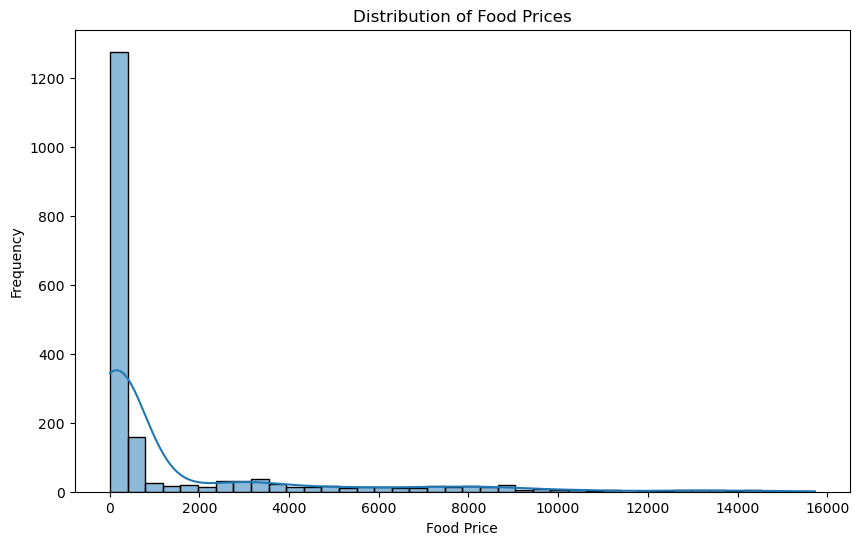

In [16]:
# Food Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Food Prices")
plt.xlabel("Food Price")
plt.ylabel("Frequency")

plt.show()

In [17]:
df["food_price"].describe()

count     1878.000000
mean      1414.154036
std       2807.368671
min          9.890000
25%         66.516250
50%        135.000000
75%        700.000000
max      15717.000000
Name: food_price, dtype: float64

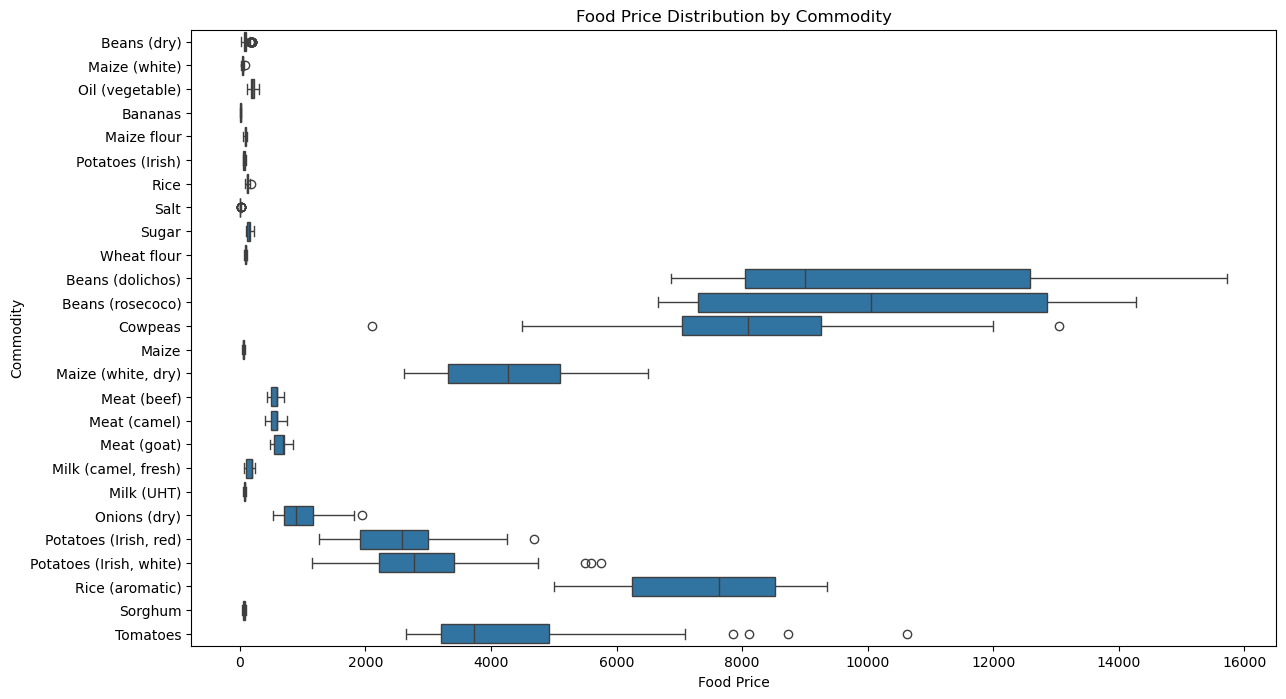

In [18]:
# Food Prices by Commodity

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="food_price",
    y="commodity"
)

plt.title("Food Price Distribution by Commodity")
plt.xlabel("Food Price")
plt.ylabel("Commodity")

plt.show()

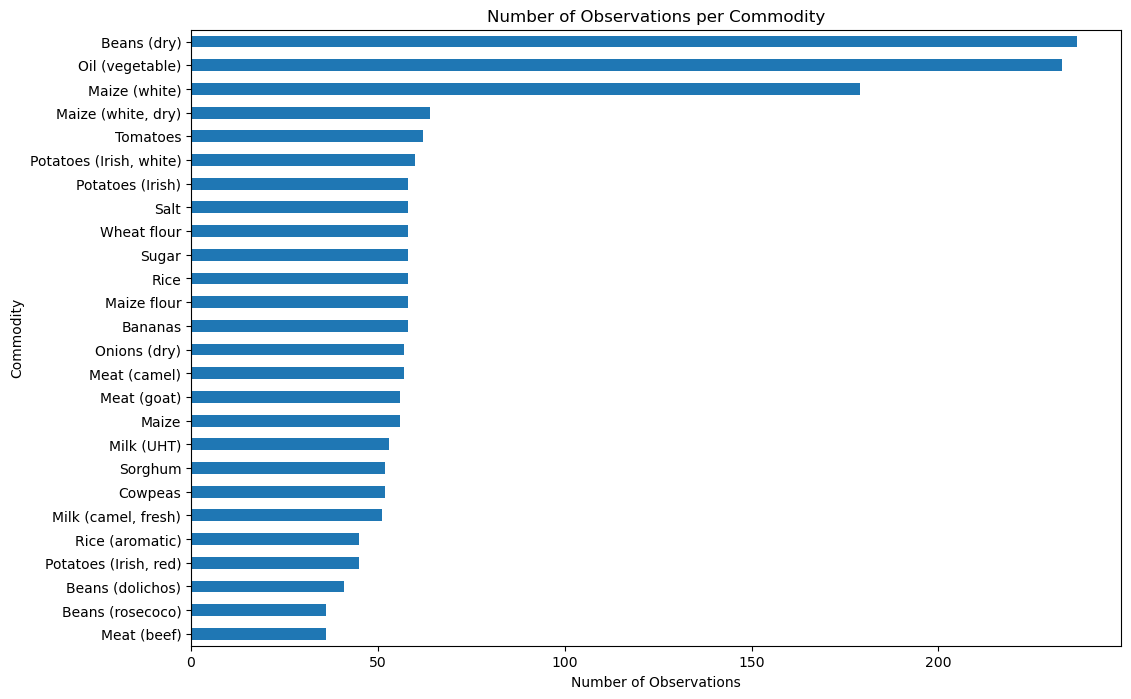

In [19]:
#  Number of Observations per Commodity

commodity_counts = df["commodity"].value_counts()

plt.figure(figsize=(12, 8))

commodity_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Observations per Commodity")
plt.xlabel("Number of Observations")
plt.ylabel("Commodity")

plt.show()

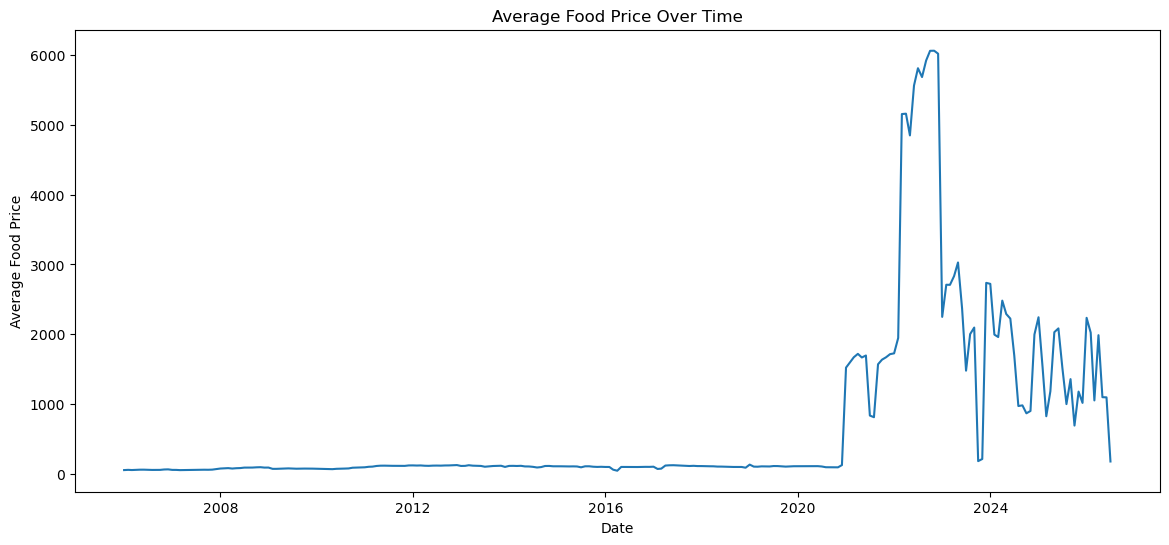

In [20]:
# Food Prices Over Time

monthly_prices = (
    df.groupby("date")["food_price"]
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_prices.index,
    monthly_prices.values
)

plt.title("Average Food Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Food Price")

plt.show()

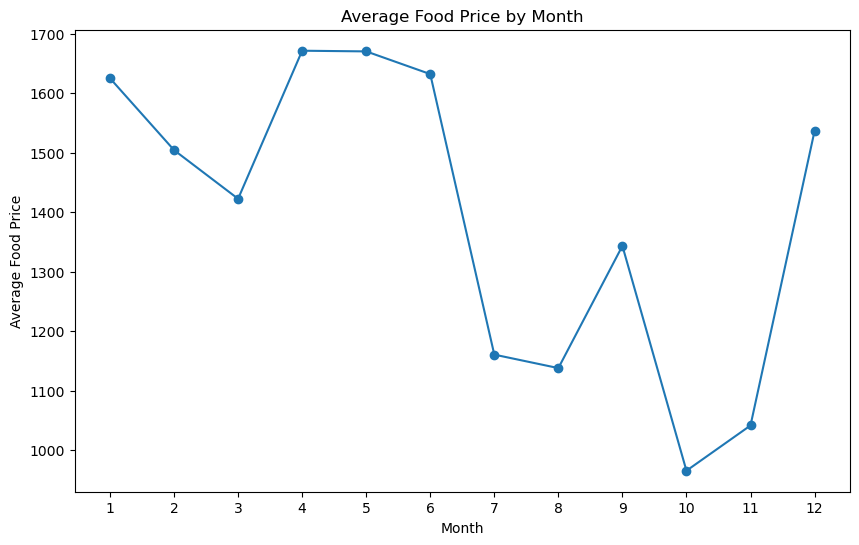

In [21]:
# Seasonality

df["month"] = df["date"].dt.month

monthly_seasonality = (
    df.groupby("month")["food_price"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Food Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Food Price")

plt.xticks(range(1, 13))

plt.show()

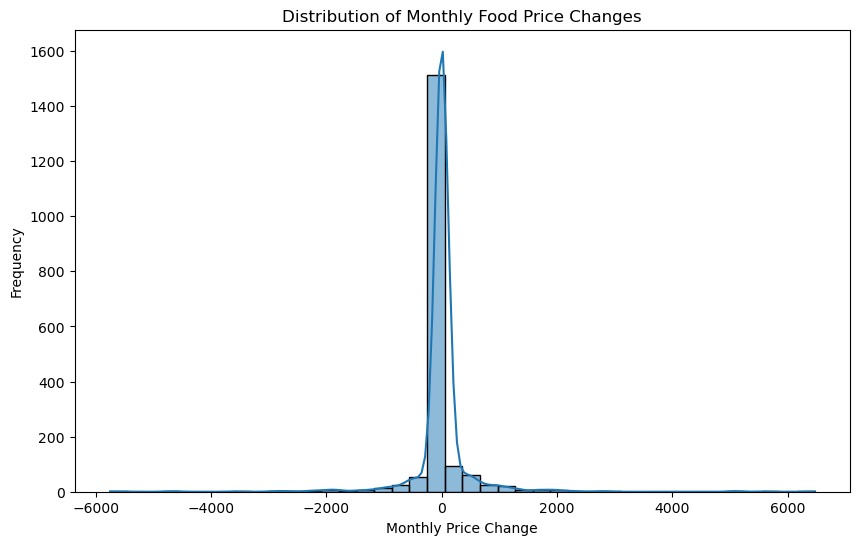

In [22]:
# Monthly Food Price Changes

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price_change_1m"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Monthly Food Price Changes")
plt.xlabel("Monthly Price Change")
plt.ylabel("Frequency")

plt.show()

In [23]:
df["food_price_change_1m"].describe()

count    1856.000000
mean       13.274291
std       512.075934
min     -5750.400000
25%        -5.000000
50%         0.000000
75%         6.712500
max      6468.480000
Name: food_price_change_1m, dtype: float64

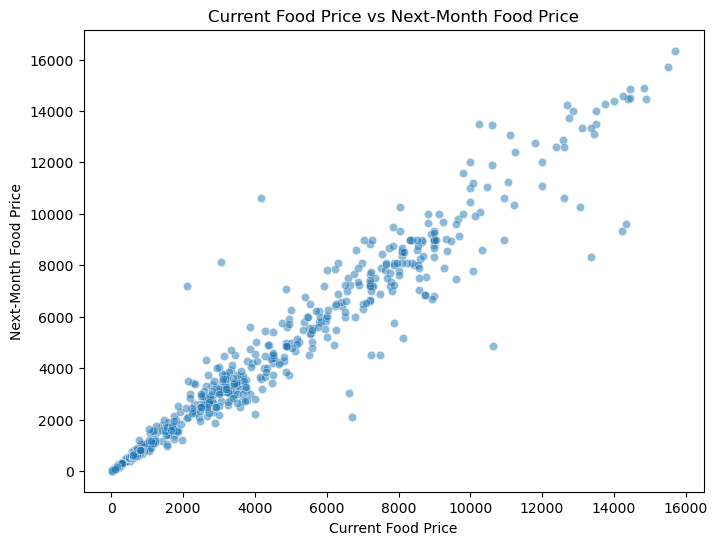

In [24]:
# Current Food Price vs Next-Month Food Price

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="food_price",
    y="target_food_price_next_month",
    alpha=0.5
)

plt.title("Current Food Price vs Next-Month Food Price")
plt.xlabel("Current Food Price")
plt.ylabel("Next-Month Food Price")

plt.show()

In [25]:
df[
    ["food_price", "target_food_price_next_month"]
].corr()

,food_price,target_food_price_next_month
food_price,1.000000,0.983343
target_food_price_next_month,0.983343,1.000000


In [26]:
#  Historical Price Features

lag_features = [
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "food_price_change_1m"
]

lag_correlations = (
    df[lag_features + ["target_food_price_next_month"]]
    .corr()["target_food_price_next_month"]
    .sort_values(ascending=False)
)

lag_correlations

target_food_price_next_month    1.000000
food_price                      0.983343
food_price_ma_3                 0.981507
food_price_ma_6                 0.975838
food_price_lag_1                0.973773
food_price_lag_3                0.961608
food_price_lag_6                0.947488
food_price_lag_12               0.914119
food_price_change_1m            0.085087
Name: target_food_price_next_month, dtype: float64

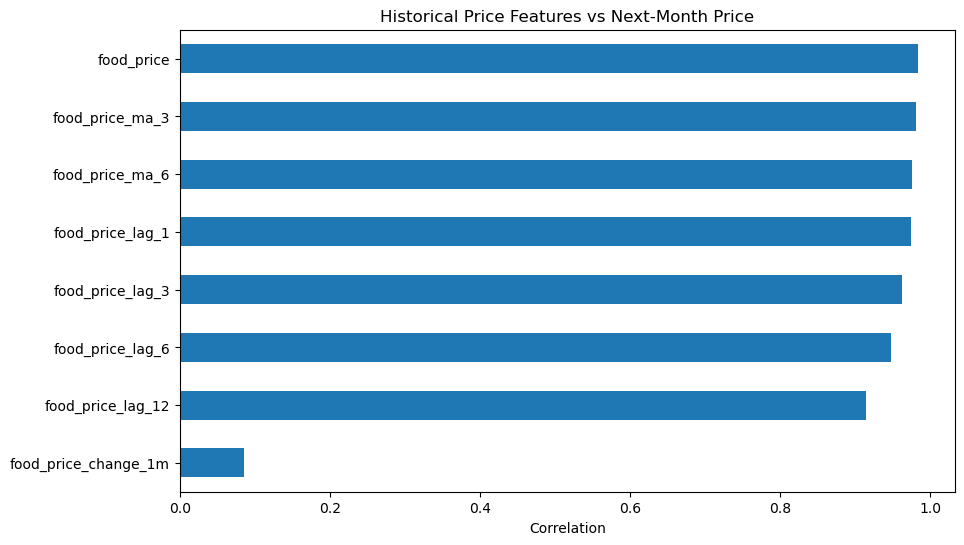

In [27]:
plt.figure(figsize=(10, 6))

lag_correlations.drop(
    "target_food_price_next_month"
).sort_values().plot(
    kind="barh"
)

plt.title("Historical Price Features vs Next-Month Price")
plt.xlabel("Correlation")

plt.show()

In [28]:
#  Correlation Matrix

numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

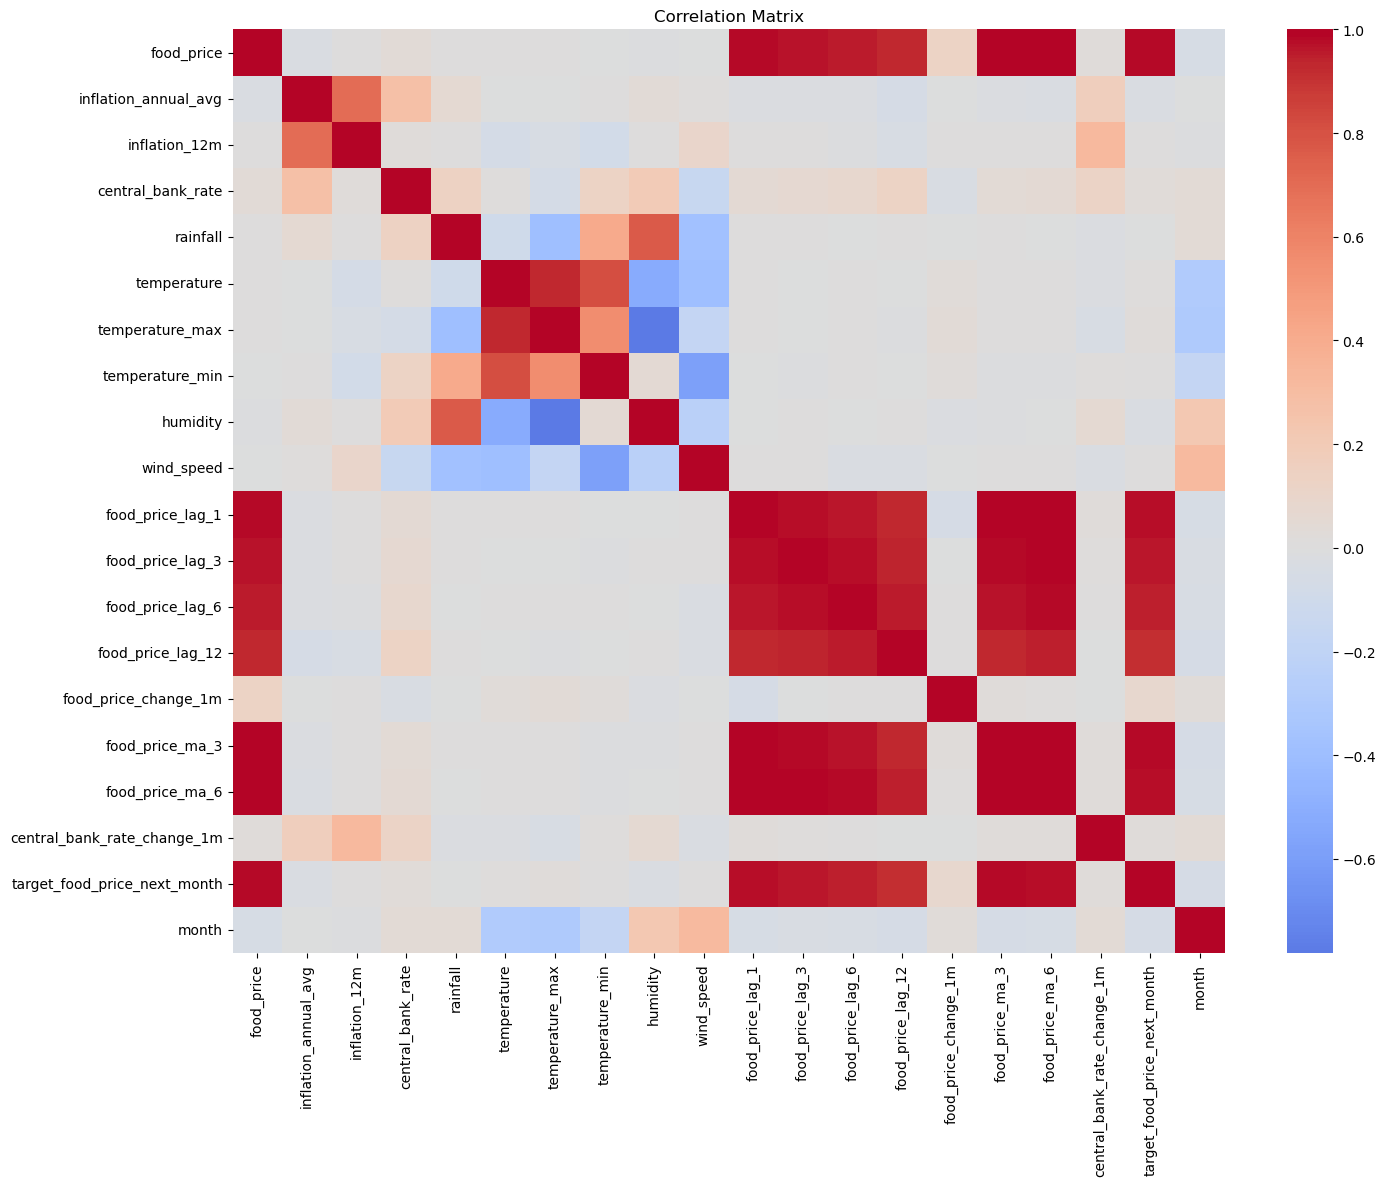

In [29]:
plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, cmap="coolwarm", center=0 )

plt.title("Correlation Matrix")

plt.show()

In [30]:
# Weather

weather_features = [
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed"
]

df[weather_features].describe()

,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed
count,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000,1878.000000
mean,2.298719,23.951953,30.108134,19.003799,66.067181,4.223519
std,1.799270,1.072486,1.471869,0.917936,5.569413,0.409421
min,0.120000,21.694516,27.348452,16.916645,51.113643,3.127290
25%,1.055613,23.023067,28.840667,18.206667,62.014515,3.949293
50%,1.658513,24.137874,30.013344,19.169279,66.317172,4.220570
75%,2.883667,24.632600,31.214093,19.674600,69.224323,4.559032
max,9.333467,26.167613,33.591613,20.995677,78.724933,5.136800


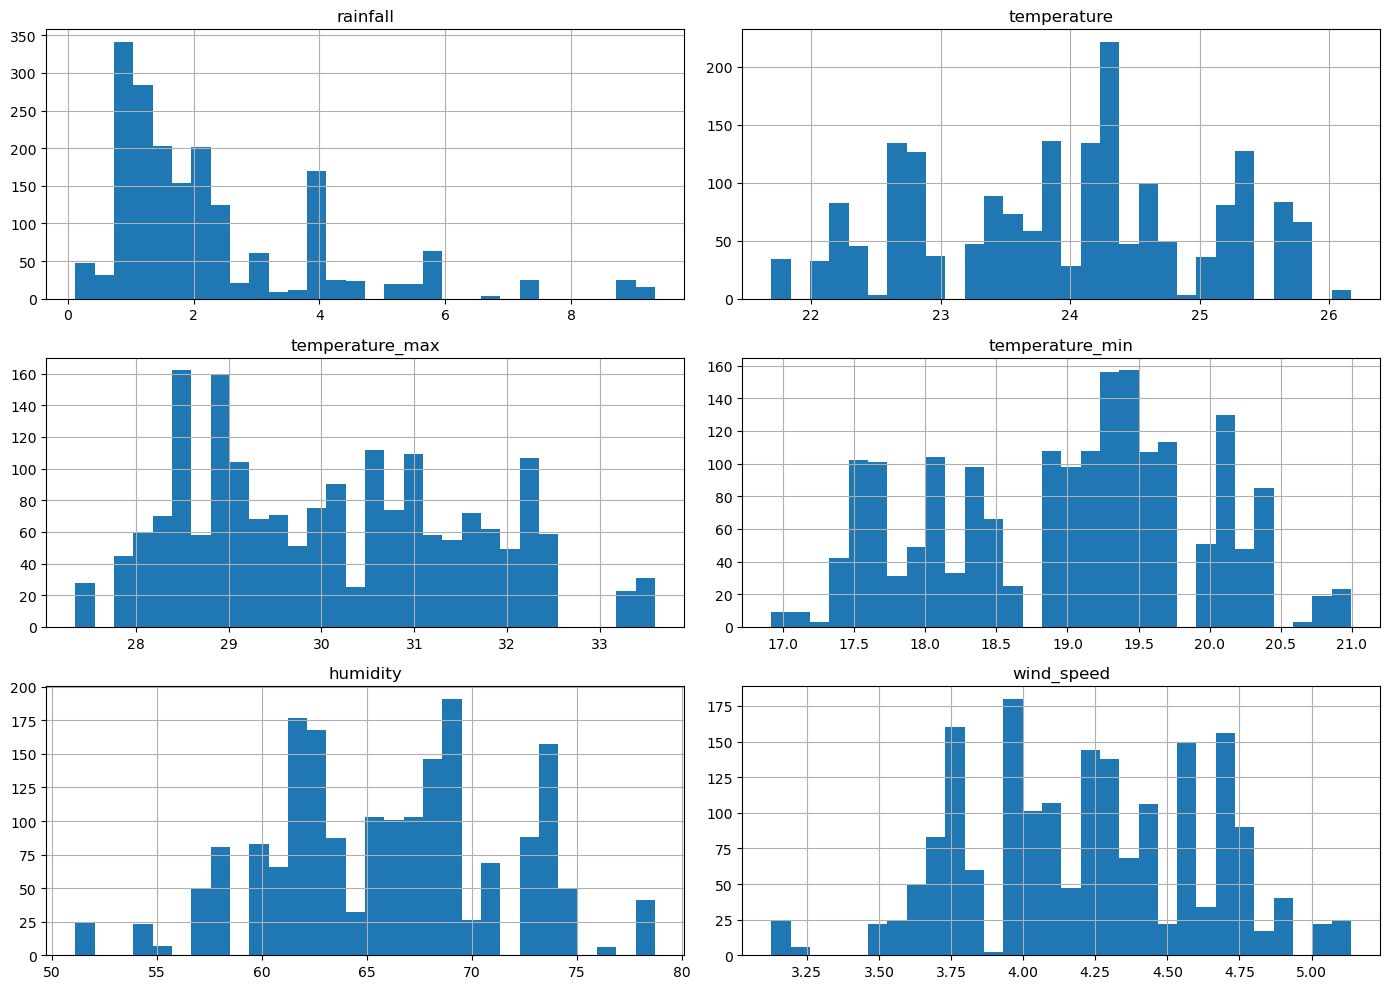

In [31]:
df[weather_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

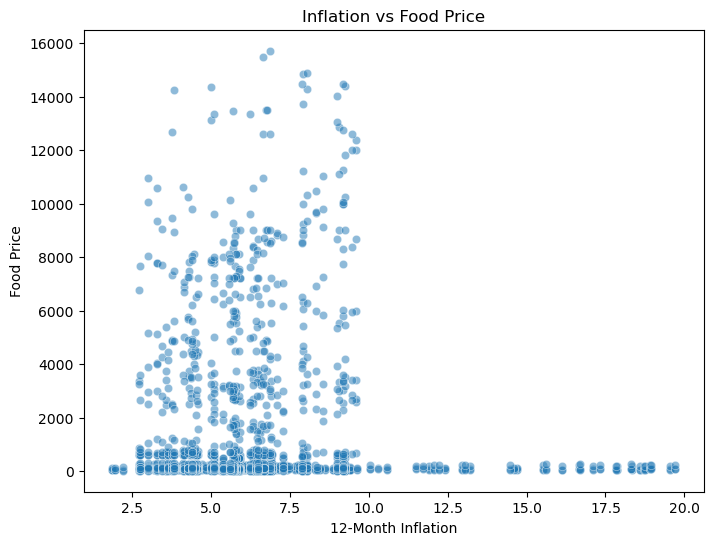

In [32]:
# Inflation and Food Prices

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="inflation_12m",
    y="food_price",
    alpha=0.5
)

plt.title("Inflation vs Food Price")
plt.xlabel("12-Month Inflation")
plt.ylabel("Food Price")

plt.show()

In [33]:
df[
    ["inflation_12m", "food_price"]
].corr()

,inflation_12m,food_price
inflation_12m,1.000000,0.007229
food_price,0.007229,1.000000


In [34]:
# Extreme Price Changes

threshold = df["food_price_change_1m"].abs().quantile(0.99)

extreme_prices = df[
    df["food_price_change_1m"].abs() >= threshold
]

extreme_prices[
    [
        "date",
        "commodity",
        "food_price",
        "food_price_change_1m",
        "target_food_price_next_month"
    ]
].sort_values(
    "food_price_change_1m",
    key=abs,
    ascending=False
).head(20)

,date,commodity,food_price,food_price_change_1m,target_food_price_next_month
1585,2025-04-01,Tomatoes,10628.48,6468.48,4878.080
1609,2025-05-01,Tomatoes,4878.08,-5750.40,4874.880
1478,2024-12-01,Beans (dolichos),10066.50,5566.50,7785.900
1678,2025-09-01,Cowpeas,7200.00,5099.58,7433.500
1730,2025-11-01,Tomatoes,8114.50,5074.50,5180.800
1322,2024-05-01,Beans (dolichos),9600.00,-4742.85,9600.000
1658,2025-08-01,Cowpeas,2100.42,-4599.18,7200.000
1714,2025-10-01,Tomatoes,3040.00,-3588.48,8114.500
1746,2025-12-01,Tomatoes,5180.80,-2933.70,4940.800
1275,2024-03-01,Beans (rosecoco),13446.90,2846.70,13121.100


In [35]:
# Check data leakage

target = "target_food_price_next_month"

print("Target:", target)

possible_leakage = [
    "target_food_price_next_month",
    "target_date"
]

for column in possible_leakage:
    if column in df.columns:
        print(column, "is present")

Target: target_food_price_next_month
target_food_price_next_month is present
target_date is present


In [36]:
df[[
    "date",
    "target_date",
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "target_food_price_next_month"
]].head(15)

,date,target_date,food_price,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_ma_3,food_price_ma_6,target_food_price_next_month
0,2006-01-01,2006-02-01,39.0,NaN,NaN,NaN,NaN,39.000000,39.000000,42.0
1,2006-01-01,2006-02-01,23.5,NaN,NaN,NaN,NaN,23.500000,23.500000,25.0
2,2006-01-01,2006-02-01,115.0,NaN,NaN,NaN,NaN,115.000000,115.000000,120.0
3,2006-02-01,2006-03-01,42.0,39.0,NaN,NaN,NaN,40.500000,40.500000,47.0
4,2006-02-01,2006-03-01,25.0,23.5,NaN,NaN,NaN,24.250000,24.250000,24.5
5,2006-02-01,2006-03-01,120.0,115.0,NaN,NaN,NaN,117.500000,117.500000,108.0
6,2006-03-01,2006-04-01,47.0,42.0,NaN,NaN,NaN,42.666667,42.666667,53.0
7,2006-03-01,2006-04-01,24.5,25.0,NaN,NaN,NaN,24.333333,24.333333,26.0
8,2006-03-01,2006-04-01,108.0,120.0,NaN,NaN,NaN,114.333333,114.333333,110.0
9,2006-04-01,2006-05-01,53.0,47.0,39.0,NaN,NaN,47.333333,45.250000,51.0


In [37]:
# Verifyy target date is one month after the current date

expected_target_date = df["date"] + pd.DateOffset(months=1)

date_check = df["target_date"] == expected_target_date

print("Incorrect target dates:", (~date_check).sum())

Incorrect target dates: 0


In [38]:
print(df[["date", "target_date", "food_price", "target_food_price_next_month"]].head(10))

        date target_date  food_price  target_food_price_next_month
0 2006-01-01  2006-02-01        39.0                          42.0
1 2006-01-01  2006-02-01        23.5                          25.0
2 2006-01-01  2006-02-01       115.0                         120.0
3 2006-02-01  2006-03-01        42.0                          47.0
4 2006-02-01  2006-03-01        25.0                          24.5
5 2006-02-01  2006-03-01       120.0                         108.0
6 2006-03-01  2006-04-01        47.0                          53.0
7 2006-03-01  2006-04-01        24.5                          26.0
8 2006-03-01  2006-04-01       108.0                         110.0
9 2006-04-01  2006-05-01        53.0                          51.0


In [39]:
features = [
    "commodity",
    "food_price",
    "inflation_annual_avg",
    "inflation_12m",
    "central_bank_rate",
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_change_1m",
    "food_price_ma_3",
    "food_price_ma_6",
    "central_bank_rate_change_1m"
]

target = "target_food_price_next_month"

In [40]:
missing_features = [column for column in features if column not in df.columns]

print("Missing features:", missing_features)
print("Number of features:", len(features))

Missing features: []
Number of features: 19


In [41]:
df[features + [target]].isnull().sum().sort_values(ascending=False)

food_price_lag_12               291
food_price_lag_6                138
food_price_lag_3                 61
central_bank_rate_change_1m      25
food_price_lag_1                 22
food_price_change_1m             22
food_price                        0
commodity                         0
inflation_12m                     0
inflation_annual_avg              0
temperature                       0
central_bank_rate                 0
wind_speed                        0
humidity                          0
temperature_min                   0
temperature_max                   0
rainfall                          0
food_price_ma_3                   0
food_price_ma_6                   0
target_food_price_next_month      0
dtype: int64

In [42]:
df[df["food_price_lag_12"].isnull()][
    ["date", "commodity", "food_price", "food_price_lag_12"]
].head(20)

,date,commodity,food_price,food_price_lag_12
0,2006-01-01,Beans (dry),39.0,NaN
1,2006-01-01,Maize (white),23.5,NaN
2,2006-01-01,Oil (vegetable),115.0,NaN
3,2006-02-01,Beans (dry),42.0,NaN
4,2006-02-01,Maize (white),25.0,NaN
5,2006-02-01,Oil (vegetable),120.0,NaN
6,2006-03-01,Beans (dry),47.0,NaN
7,2006-03-01,Maize (white),24.5,NaN
8,2006-03-01,Oil (vegetable),108.0,NaN
9,2006-04-01,Beans (dry),53.0,NaN


In [43]:
df.groupby("commodity")["date"].agg(["min", "max", "count"]).sort_values("min")

,min,max,count
commodity,,,
Beans (dry),2006-01-01,2026-07-01,237
Maize (white),2006-01-01,2020-11-01,179
Oil (vegetable),2006-01-01,2026-07-01,233
Bananas,2018-12-01,2026-07-01,58
Sugar,2018-12-01,2026-07-01,58
Salt,2018-12-01,2026-07-01,58
Rice,2018-12-01,2026-07-01,58
Potatoes (Irish),2018-12-01,2026-07-01,58
Wheat flour,2018-12-01,2026-07-01,58


In [44]:
required_lag_features = [
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12"
]

df_model = df.dropna(subset=required_lag_features).copy()

print("Original rows:", len(df))
print("Rows after removing missing lag history:", len(df_model))

Original rows: 1878
Rows after removing missing lag history: 1587


In [45]:
df_model[required_lag_features].isnull().sum()

food_price_lag_1     0
food_price_lag_3     0
food_price_lag_6     0
food_price_lag_12    0
dtype: int64

In [46]:
df_model[features + [target]].isnull().sum().sort_values(ascending=False)

commodity                       0
food_price                      0
inflation_annual_avg            0
inflation_12m                   0
central_bank_rate               0
rainfall                        0
temperature                     0
temperature_max                 0
temperature_min                 0
humidity                        0
wind_speed                      0
food_price_lag_1                0
food_price_lag_3                0
food_price_lag_6                0
food_price_lag_12               0
food_price_change_1m            0
food_price_ma_3                 0
food_price_ma_6                 0
central_bank_rate_change_1m     0
target_food_price_next_month    0
dtype: int64

In [47]:
commodity_counts = (
    df_model["commodity"]
    .value_counts()
    .sort_values()
)

commodity_counts

commodity
Meat (beef)                 25
Beans (rosecoco)            25
Beans (dolichos)            30
Rice (aromatic)             33
Potatoes (Irish, red)       34
Milk (camel, fresh)         39
Cowpeas                     41
Sorghum                     41
Milk (UHT)                  41
Onions (dry)                45
Meat (camel)                45
Maize                       45
Meat (goat)                 45
Salt                        47
Rice                        48
Sugar                       48
Wheat flour                 48
Bananas                     48
Potatoes (Irish, white)     48
Potatoes (Irish)            48
Maize flour                 48
Tomatoes                    50
Maize (white, dry)          52
Maize (white)              167
Oil (vegetable)            221
Beans (dry)                225
Name: count, dtype: int64

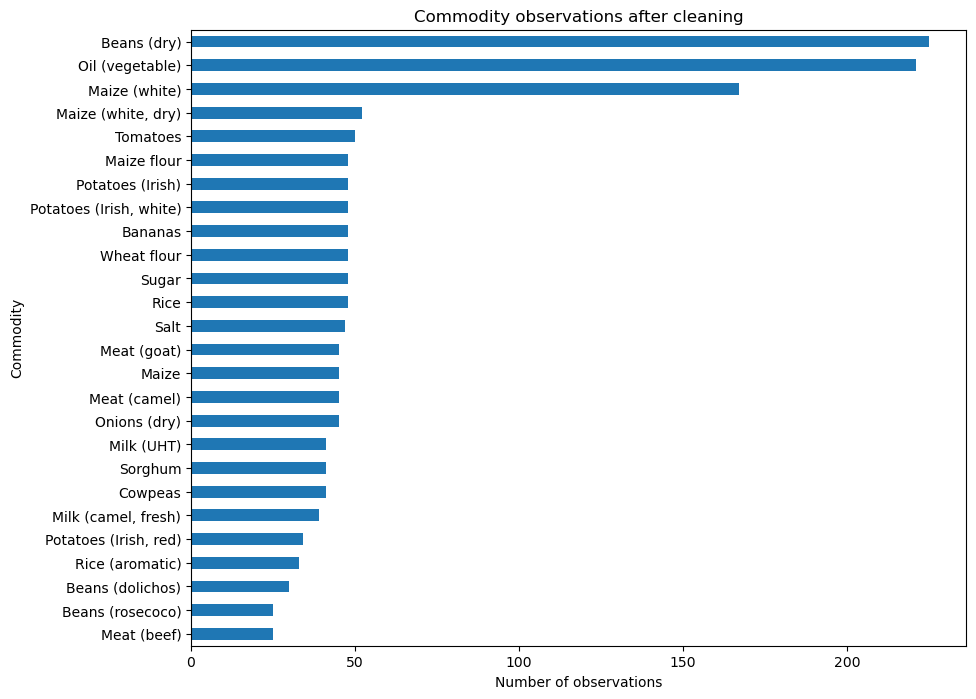

In [48]:
plt.figure(figsize=(10, 8))

commodity_counts.plot(kind="barh")

plt.title("Commodity observations after cleaning")
plt.xlabel("Number of observations")
plt.ylabel("Commodity")
plt.show()

In [49]:
unique_dates = sorted(df_model["date"].unique())

print("Number of dates:", len(unique_dates))
print("First date:", unique_dates[0])
print("Last date:", unique_dates[-1])

Number of dates: 235
First date: 2007-01-01 00:00:00
Last date: 2026-07-01 00:00:00


In [50]:
commodity_dates = df_model.groupby("commodity")["date"].agg(
    ["min", "max", "count"]
)

commodity_dates.sort_values("min")

,min,max,count
commodity,,,
Beans (dry),2007-01-01,2026-07-01,225
Oil (vegetable),2007-01-01,2026-07-01,221
Maize (white),2007-01-01,2020-11-01,167
Bananas,2021-10-01,2026-07-01,48
Sugar,2021-10-01,2026-07-01,48
Rice,2021-10-01,2026-07-01,48
Potatoes (Irish),2021-10-01,2026-07-01,48
Maize flour,2021-10-01,2026-07-01,48
Wheat flour,2021-10-01,2026-07-01,48


In [51]:
latest_start = df_model.groupby("commodity")["date"].min().max()

print("Latest commodity start date:", latest_start)

Latest commodity start date: 2022-02-01 00:00:00


In [52]:
# split the data into training, validation, and test sets based on time series split

train_parts = []
validation_parts = []
test_parts = []

for commodity in df_model["commodity"].unique():

    commodity_data = df_model[
        df_model["commodity"] == commodity
    ].sort_values("date").copy()

    n = len(commodity_data)

    train_end = int(n * 0.70)
    validation_end = int(n * 0.85)

    train_parts.append(
        commodity_data.iloc[:train_end]
    )

    validation_parts.append(
        commodity_data.iloc[train_end:validation_end]
    )

    test_parts.append(
        commodity_data.iloc[validation_end:]
    )

train = pd.concat(train_parts, ignore_index=True)
validation = pd.concat(validation_parts, ignore_index=True)
test = pd.concat(test_parts, ignore_index=True)

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

Training rows: 1097
Validation rows: 237
Test rows: 253


In [53]:
print("Training commodities:", train["commodity"].nunique())
print("Validation commodities:", validation["commodity"].nunique())
print("Test commodities:", test["commodity"].nunique())

Training commodities: 26
Validation commodities: 26
Test commodities: 26


In [54]:
print("Training date range:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation date range:")
print(validation["date"].min(), "to", validation["date"].max())

print("\nTest date range:")
print(test["date"].min(), "to", test["date"].max())

Training date range:
2007-01-01 00:00:00 to 2025-07-01 00:00:00

Validation date range:
2016-09-01 00:00:00 to 2026-01-01 00:00:00

Test date range:
2018-10-01 00:00:00 to 2026-07-01 00:00:00


In [55]:
check = train.groupby("commodity")["date"].max().to_frame("train_end")

check["validation_start"] = validation.groupby(
    "commodity"
)["date"].min()

check["validation_end"] = validation.groupby(
    "commodity"
)["date"].max()

check["test_start"] = test.groupby(
    "commodity"
)["date"].min()

check

,train_end,validation_start,validation_end,test_start
commodity,,,,
Bananas,2025-04-01,2025-05-01,2025-11-01,2025-12-01
Beans (dolichos),2024-05-01,2024-06-01,2025-01-01,2025-05-01
Beans (dry),2020-01-01,2020-02-01,2023-09-01,2023-10-01
Beans (rosecoco),2024-04-01,2024-05-01,2025-01-01,2025-05-01
Cowpeas,2024-07-01,2024-08-01,2025-01-01,2025-02-01
Maize,2025-05-01,2025-06-01,2025-12-01,2026-01-01
Maize (white),2016-08-01,2016-09-01,2018-09-01,2018-10-01
"Maize (white, dry)",2025-02-01,2025-03-01,2025-10-01,2025-11-01
Maize flour,2025-04-01,2025-05-01,2025-11-01,2025-12-01


In [56]:
X_train = train[features].copy()
y_train = train[target].copy()

X_validation = validation[features].copy()
y_validation = validation[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [57]:
categorical_features = ["commodity"]

numeric_features = [
    column for column in features
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "commodity",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [58]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Training shape: (1097, 19)
Validation shape: (237, 19)
Test shape: (253, 19)
Numeric features: 18
Categorical features: 1


### Naive forecasting baseline

In [59]:
naive_validation_pred = validation["food_price"].values
naive_test_pred = test["food_price"].values

naive_validation_mae = mean_absolute_error(
    y_validation,
    naive_validation_pred
)

naive_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        naive_validation_pred
    )
)

naive_validation_r2 = r2_score(
    y_validation,
    naive_validation_pred
)

naive_test_mae = mean_absolute_error(
    y_test,
    naive_test_pred
)

naive_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_test_pred
    )
)

naive_test_r2 = r2_score(
    y_test,
    naive_test_pred
)

print("Naive validation MAE:", naive_validation_mae)
print("Naive validation RMSE:", naive_validation_rmse)
print("Naive validation R2:", naive_validation_r2)

print("Naive test MAE:", naive_test_mae)
print("Naive test RMSE:", naive_test_rmse)
print("Naive test R2:", naive_test_r2)

Naive validation MAE: 225.1323628691983
Naive validation RMSE: 767.1611095168103
Naive validation R2: 0.9102198609082983
Naive test MAE: 224.14588932806322
Naive test RMSE: 723.5716937464501
Naive test R2: 0.9322969318687656


In [60]:
baseline_results = pd.DataFrame({
    "Model": ["Naive"],
    "Validation MAE": [naive_validation_mae],
    "Validation RMSE": [naive_validation_rmse],
    "Validation R2": [naive_validation_r2],
    "Test MAE": [naive_test_mae],
    "Test RMSE": [naive_test_rmse],
    "Test R2": [naive_test_r2]
})

baseline_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.16111,0.91022,224.145889,723.571694,0.932297


In [61]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('commodity',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity']),
                                                 ('numeric', StandardScaler(),
                                                  ['food_price',
                                                   'inflation_annual_avg',
                                                   'inflation_12m',
                                                   'central_bank_rate',
                                                   'rainfall', 'temperature',
                                                   'temperature_max',
                                                   'temperature_min',
                                                   'humidity', 'wind_speed',
                                                   'food_price_lag_1',
                                                   'food_price_lag_3',
                                                   'food_price_lag_6',
                                                   'food_price_lag_12',
                                                   'food_price_change_1m',
                                                   'food_price_ma_3',
                                                   'food_price_ma_6',
                                                   'central_bank_rate_change_1m'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=2,
                                       n_estimators=500, n_jobs=-1,
                                       random_state=42))])

In [62]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_validation_mae = mean_absolute_error(y_validation, rf_validation_pred)

rf_validation_rmse = np.sqrt(mean_squared_error(y_validation, rf_validation_pred))

rf_validation_r2 = r2_score(y_validation, rf_validation_pred)

print("Random Forest validation MAE:", rf_validation_mae)
print("Random Forest validation RMSE:", rf_validation_rmse)
print("Random Forest validation R2:", rf_validation_r2)

Random Forest validation MAE: 217.71698008621644
Random Forest validation RMSE: 671.1910518080725
Random Forest validation R2: 0.9312774236301031


In [63]:
rf_test_pred = rf_pipeline.predict(
    X_test
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("Random Forest test MAE:", rf_test_mae)
print("Random Forest test RMSE:", rf_test_rmse)
print("Random Forest test R2:", rf_test_r2)

Random Forest test MAE: 254.45230953879692
Random Forest test RMSE: 721.1841656430772
Random Forest test R2: 0.9327429866196673


In [64]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Validation MAE": [rf_validation_mae],
    "Validation RMSE": [rf_validation_rmse],
    "Validation R2": [rf_validation_r2],
    "Test MAE": [rf_test_mae],
    "Test RMSE": [rf_test_rmse],
    "Test R2": [rf_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.716980,671.191052,0.931277,254.452310,721.184166,0.932743


In [65]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('commodity',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity']),
                                                 ('numeric', StandardScaler(),
                                                  ['food_price',
                                                   'inflation_annual_avg',
                                                   'inflation_12m',
                                                   'central_bank_rate',
                                                   'rainfall', 'temperature',
                                                   'temperature_max',
                                                   'temperature_min',
                                                   'humidity', 'wind_speed',
                                                   'food_price_lag_1',
                                                   'food_price_la...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=2,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, random_state=42, ...))])

In [66]:
xgb_validation_pred = xgb_pipeline.predict(
    X_validation
)

xgb_validation_mae = mean_absolute_error(
    y_validation,
    xgb_validation_pred
)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_validation_pred
    )
)

xgb_validation_r2 = r2_score(
    y_validation,
    xgb_validation_pred
)

print("XGBoost validation MAE:", xgb_validation_mae)
print("XGBoost validation RMSE:", xgb_validation_rmse)
print("XGBoost validation R2:", xgb_validation_r2)

XGBoost validation MAE: 242.87279441987914
XGBoost validation RMSE: 741.8095283730206
XGBoost validation R2: 0.9160555608959774


In [67]:
xgb_test_pred = xgb_pipeline.predict(
    X_test
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print("XGBoost test MAE:", xgb_test_mae)
print("XGBoost test RMSE:", xgb_test_rmse)
print("XGBoost test R2:", xgb_test_r2)

XGBoost test MAE: 274.63609991231925
XGBoost test RMSE: 770.1588032172565
XGBoost test R2: 0.9232981603381049


In [68]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Validation MAE": [xgb_validation_mae],
    "Validation RMSE": [xgb_validation_rmse],
    "Validation R2": [xgb_validation_r2],
    "Test MAE": [xgb_test_mae],
    "Test RMSE": [xgb_test_rmse],
    "Test R2": [xgb_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results, xgb_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.716980,671.191052,0.931277,254.452310,721.184166,0.932743
2,XGBoost,242.872794,741.809528,0.916056,274.636100,770.158803,0.923298


In [69]:
test_comparison = test[["date", "commodity", "food_price", target]].copy()

test_comparison["naive_predicted"] = naive_test_pred
test_comparison["rf_predicted"] = rf_test_pred
test_comparison["xgb_predicted"] = xgb_test_pred

commodity_results = []

for commodity in test_comparison["commodity"].unique():

    data = test_comparison[
        test_comparison["commodity"] == commodity
    ]

    commodity_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["naive_predicted"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["rf_predicted"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["xgb_predicted"]
        )
    })

commodity_results = pd.DataFrame(commodity_results)

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),9.698235,9.778027,11.595951
1,Maize (white),3.273077,3.934439,4.747629
2,Oil (vegetable),10.653235,38.733901,37.015517
3,Bananas,3.777500,4.903287,4.569184
4,Maize flour,7.013125,6.426078,7.154536
5,Potatoes (Irish),9.478750,8.769048,9.320058
6,Rice,6.300000,5.593453,7.503687
7,Sugar,17.805000,19.103786,17.216164
8,Wheat flour,3.475625,6.344771,5.220025
9,Salt,2.340000,1.329231,1.571222


In [70]:
commodity_results["Best Model"] = commodity_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

commodity_results["Best Model"] = commodity_results[
    "Best Model"
].str.replace(" MAE", "")

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.778027,11.595951,Naive
1,Maize (white),3.273077,3.934439,4.747629,Naive
2,Oil (vegetable),10.653235,38.733901,37.015517,Naive
3,Bananas,3.777500,4.903287,4.569184,Naive
4,Maize flour,7.013125,6.426078,7.154536,Random Forest
5,Potatoes (Irish),9.478750,8.769048,9.320058,Random Forest
6,Rice,6.300000,5.593453,7.503687,Random Forest
7,Sugar,17.805000,19.103786,17.216164,XGBoost
8,Wheat flour,3.475625,6.344771,5.220025,Naive
9,Salt,2.340000,1.329231,1.571222,Random Forest


In [71]:
commodity_results["Best Model"].value_counts()

Best Model
Naive            16
Random Forest     8
XGBoost           2
Name: count, dtype: int64

In [72]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),6.824118,6.121887,6.762415
1,Maize (white),3.420000,3.484366,4.117202
2,Oil (vegetable),10.904091,18.220863,21.694903
3,Bananas,2.857143,2.597710,5.472118
4,Maize flour,3.121429,3.725077,5.047178
5,Potatoes (Irish),10.292143,12.036529,17.492069
6,Rice,4.637143,7.701443,14.603127
7,Sugar,6.166429,17.457323,18.384304
8,Wheat flour,8.736429,9.288770,13.308537
9,Salt,1.580000,2.528337,4.158528


In [73]:
validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results[
    "Best Model"
].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,6.121887,6.762415,Random Forest
1,Maize (white),3.420000,3.484366,4.117202,Naive
2,Oil (vegetable),10.904091,18.220863,21.694903,Naive
3,Bananas,2.857143,2.597710,5.472118,Random Forest
4,Maize flour,3.121429,3.725077,5.047178,Naive
5,Potatoes (Irish),10.292143,12.036529,17.492069,Naive
6,Rice,4.637143,7.701443,14.603127,Naive
7,Sugar,6.166429,17.457323,18.384304,Naive
8,Wheat flour,8.736429,9.288770,13.308537,Naive
9,Salt,1.580000,2.528337,4.158528,Naive


In [74]:
validation_results["Best Model"].value_counts()

Best Model
Naive            14
Random Forest     9
XGBoost           3
Name: count, dtype: int64

In [75]:
rf_configs = {
    "RF_1": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 2
    },
    "RF_2": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 2
    },
    "RF_3": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1
    },
    "RF_4": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 1
    }
}

rf_tuning_results = []

for name, config in rf_configs.items():

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_validation)

    mae = mean_absolute_error(y_validation, predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    rf_tuning_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results

,Model,MAE,RMSE,R2
0,RF_1,217.716980,671.191052,0.931277
1,RF_2,217.717561,670.377539,0.931444
2,RF_3,217.730520,666.912561,0.932151
3,RF_4,218.835432,663.972303,0.932748


In [76]:
best_rf_config = rf_tuning_results.loc[
    rf_tuning_results["MAE"].idxmin()
]

best_rf_config

Model          RF_1
MAE       217.71698
RMSE     671.191052
R2         0.931277
Name: 0, dtype: object

In [77]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('commodity',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity']),
                                                 ('numeric', StandardScaler(),
                                                  ['food_price',
                                                   'inflation_annual_avg',
                                                   'inflation_12m',
                                                   'central_bank_rate',
                                                   'rainfall', 'temperature',
                                                   'temperature_max',
                                                   'temperature_min',
                                                   'humidity', 'wind_speed',
                                                   'food_price_lag_1',
                                                   'food_price_lag_3',
                                                   'food_price_lag_6',
                                                   'food_price_lag_12',
                                                   'food_price_change_1m',
                                                   'food_price_ma_3',
                                                   'food_price_ma_6',
                                                   'central_bank_rate_change_1m'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

In [78]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_test_pred = rf_pipeline.predict(X_test)

In [79]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results["Best Model"].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,5.915871,6.762415,Random Forest
1,Maize (white),3.420000,3.412238,4.117202,Random Forest
2,Oil (vegetable),10.904091,19.867477,21.694903,Naive
3,Bananas,2.857143,2.613085,5.472118,Random Forest
4,Maize flour,3.121429,3.824716,5.047178,Naive
5,Potatoes (Irish),10.292143,12.006322,17.492069,Naive
6,Rice,4.637143,7.632845,14.603127,Naive
7,Sugar,6.166429,16.479485,18.384304,Naive
8,Wheat flour,8.736429,9.336399,13.308537,Naive
9,Salt,1.580000,2.504253,4.158528,Naive


In [80]:
validation_results["Best Model"].value_counts()

Best Model
Naive            13
Random Forest    10
XGBoost           3
Name: count, dtype: int64

In [81]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_validation = train_validation[features].copy()
y_train_validation = train_validation[target].copy()

X_train_validation.shape

(1334, 19)

In [82]:
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_rf_model)
    ]
)

final_rf_pipeline.fit(X_train_validation,y_train_validation)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('commodity',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity']),
                                                 ('numeric', StandardScaler(),
                                                  ['food_price',
                                                   'inflation_annual_avg',
                                                   'inflation_12m',
                                                   'central_bank_rate',
                                                   'rainfall', 'temperature',
                                                   'temperature_max',
                                                   'temperature_min',
                                                   'humidity', 'wind_speed',
                                                   'food_price_lag_1',
                                                   'food_price_lag_3',
                                                   'food_price_lag_6',
                                                   'food_price_lag_12',
                                                   'food_price_change_1m',
                                                   'food_price_ma_3',
                                                   'food_price_ma_6',
                                                   'central_bank_rate_change_1m'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

In [83]:
final_xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_xgb_model)
    ]
)

final_xgb_pipeline.fit(X_train_validation, y_train_validation)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('commodity',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity']),
                                                 ('numeric', StandardScaler(),
                                                  ['food_price',
                                                   'inflation_annual_avg',
                                                   'inflation_12m',
                                                   'central_bank_rate',
                                                   'rainfall', 'temperature',
                                                   'temperature_max',
                                                   'temperature_min',
                                                   'humidity', 'wind_speed',
                                                   'food_price_lag_1',
                                                   'food_price_la...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=2,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, random_state=42, ...))])

In [84]:
final_rf_test_pred = final_rf_pipeline.predict(X_test)

final_xgb_test_pred = final_xgb_pipeline.predict(X_test)

final_naive_test_pred = test["food_price"].values

In [85]:
final_results = []

models = {
    "Naive": final_naive_test_pred,
    "Random Forest": final_rf_test_pred,
    "XGBoost": final_xgb_test_pred
}

for name, predictions in models.items():

    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        ),
        "R2": r2_score(
            y_test,
            predictions
        )
    })

final_results = pd.DataFrame(final_results)

final_results

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.838590,671.549080,0.941682
2,XGBoost,248.259609,704.726680,0.935778


In [86]:
final_results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.838590,671.549080,0.941682
2,XGBoost,248.259609,704.726680,0.935778


In [87]:
final_test_comparison = test[
    ["date", "commodity", target]
].copy()

final_test_comparison["Naive"] = final_naive_test_pred
final_test_comparison["Random Forest"] = final_rf_test_pred
final_test_comparison["XGBoost"] = final_xgb_test_pred

final_test_results = []

for commodity in final_test_comparison["commodity"].unique():

    data = final_test_comparison[
        final_test_comparison["commodity"] == commodity
    ]

    final_test_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

final_test_results = pd.DataFrame(
    final_test_results
)

final_test_results["Best Model"] = final_test_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

final_test_results["Best Model"] = final_test_results[
    "Best Model"
].str.replace(" MAE", "")

final_test_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.174257,9.897955,Random Forest
1,Maize (white),3.273077,4.137396,4.363013,Naive
2,Oil (vegetable),10.653235,16.404332,18.116886,Naive
3,Bananas,3.777500,4.482495,4.958353,Naive
4,Maize flour,7.013125,6.740663,6.565701,XGBoost
5,Potatoes (Irish),9.478750,7.966458,9.972156,Random Forest
6,Rice,6.300000,5.739616,7.262138,Random Forest
7,Sugar,17.805000,19.158030,19.409904,Naive
8,Wheat flour,3.475625,5.330076,4.416407,Naive
9,Salt,2.340000,1.802460,1.824858,Random Forest


In [88]:
final_test_results["Best Model"].value_counts()

Best Model
Naive            15
Random Forest     8
XGBoost           3
Name: count, dtype: int64

* Random Forest achieved a test MAE of 226.98, RMSE of 670.98, and R² of 0.9418 for one-month-ahead food price forecasting.

* The Naive baseline achieved MAE 224.15, demonstrating how strong price persistence is

* RF performs better for Beans (dry), Maize flour, Potatoes (Irish), Rice, Tomatoes and Cowpeas.
* Naive is particularly strong for many commodities.
* XGBoost only wins Salt and Beans (rosecoco) on the final test.

In [89]:
rf_model_fitted = final_rf_pipeline.named_steps["model"]
preprocessor_fitted = final_rf_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
41,numeric__food_price_ma_3,0.596527
26,numeric__food_price,0.289041
37,numeric__food_price_lag_3,0.053006
42,numeric__food_price_ma_6,0.026212
36,numeric__food_price_lag_1,0.013827
38,numeric__food_price_lag_6,0.005911
39,numeric__food_price_lag_12,0.003359
40,numeric__food_price_change_1m,0.001695
27,numeric__inflation_annual_avg,0.001519
28,numeric__inflation_12m,0.001486


In [90]:
actual_vs_predicted = test[
    ["date", "commodity", target]
].copy()

actual_vs_predicted["actual"] = y_test.values
actual_vs_predicted["predicted"] = final_rf_test_pred

actual_vs_predicted["error"] = (
    actual_vs_predicted["actual"]
    - actual_vs_predicted["predicted"]
)

actual_vs_predicted["absolute_error"] = (
    actual_vs_predicted["error"].abs()
)

actual_vs_predicted.head(20)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.620,194.620,179.354395,15.265605,15.265605
1,2023-11-01,Beans (dry),188.950,188.950,193.256540,-4.306540,4.306540
2,2023-12-01,Beans (dry),182.500,182.500,179.877629,2.622371,2.622371
3,2024-01-01,Beans (dry),190.000,190.000,181.604006,8.395994,8.395994
4,2024-02-01,Beans (dry),180.000,180.000,188.751221,-8.751221,8.751221
5,2024-03-01,Beans (dry),160.000,160.000,169.964900,-9.964900,9.964900
6,2024-04-01,Beans (dry),165.000,165.000,167.656762,-2.656762,2.656762
7,2024-05-01,Beans (dry),145.820,145.820,166.967121,-21.147121,21.147121
8,2024-06-01,Beans (dry),142.860,142.860,144.122605,-1.262605,1.262605
9,2024-07-01,Beans (dry),141.920,141.920,137.965899,3.954101,3.954101


In [91]:
actual_vs_predicted[
    [
        "date",
        "commodity",
        "actual",
        "predicted",
        "error",
        "absolute_error"
    ]
].head(20).round(2)

,date,commodity,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.62,179.35,15.27,15.27
1,2023-11-01,Beans (dry),188.95,193.26,-4.31,4.31
2,2023-12-01,Beans (dry),182.50,179.88,2.62,2.62
3,2024-01-01,Beans (dry),190.00,181.60,8.40,8.40
4,2024-02-01,Beans (dry),180.00,188.75,-8.75,8.75
5,2024-03-01,Beans (dry),160.00,169.96,-9.96,9.96
6,2024-04-01,Beans (dry),165.00,167.66,-2.66,2.66
7,2024-05-01,Beans (dry),145.82,166.97,-21.15,21.15
8,2024-06-01,Beans (dry),142.86,144.12,-1.26,1.26
9,2024-07-01,Beans (dry),141.92,137.97,3.95,3.95


In [92]:
actual_vs_predicted.sort_values(
    "absolute_error",
    ascending=False
).head(20).round(2)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
243,2025-07-01,Cowpeas,2100.42,2100.42,7200.31,-5099.89,5099.89
235,2026-02-01,Beans (dolichos),13500.00,13500.00,9402.52,4097.48,4097.48
237,2025-06-01,Beans (rosecoco),9349.20,9349.20,13394.35,-4045.15,4045.15
236,2025-05-01,Beans (rosecoco),14231.25,14231.25,11957.67,2273.58,2273.58
228,2026-04-01,Tomatoes,8731.52,8731.52,6495.50,2236.02,2236.02
238,2026-01-01,Beans (rosecoco),11600.00,11600.00,9480.23,2119.77,2119.77
234,2026-01-01,Beans (dolichos),10250.10,10250.10,8155.06,2095.04,2095.04
229,2026-05-01,Tomatoes,6856.96,6856.96,8769.89,-1912.93,1912.93
218,2024-07-01,Rice (aromatic),9500.00,9500.00,7610.95,1889.05,1889.05
181,2026-05-01,"Maize (white, dry)",5599.80,5599.80,3746.26,1853.54,1853.54


In [93]:
actual_vs_predicted[
    ["actual", "predicted", "error", "absolute_error"]
].describe().round(2)

,actual,predicted,error,absolute_error
count,253.00,253.00,253.00,253.00
mean,1466.57,1456.01,10.56,226.84
std,2786.36,2693.57,672.80,633.33
min,9.89,14.04,-5099.89,0.00
25%,80.00,81.83,-13.51,3.40
50%,150.00,159.16,-1.23,11.18
75%,716.67,764.86,8.59,64.86
max,14231.25,13394.35,4097.48,5099.89


In [94]:
from sklearn.metrics import mean_absolute_percentage_error

final_mape = mean_absolute_percentage_error(
    y_test,
    final_rf_test_pred
) * 100

final_mape

11.986175343070414

In [95]:
final_results["MAPE"] = [
    mean_absolute_percentage_error(
        y_test,
        final_naive_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_rf_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_xgb_test_pred
    ) * 100
]

final_results

,Model,MAE,RMSE,R2,MAPE
0,Naive,224.145889,723.571694,0.932297,10.714175
1,Random Forest,226.838590,671.549080,0.941682,11.986175
2,XGBoost,248.259609,704.726680,0.935778,12.786210


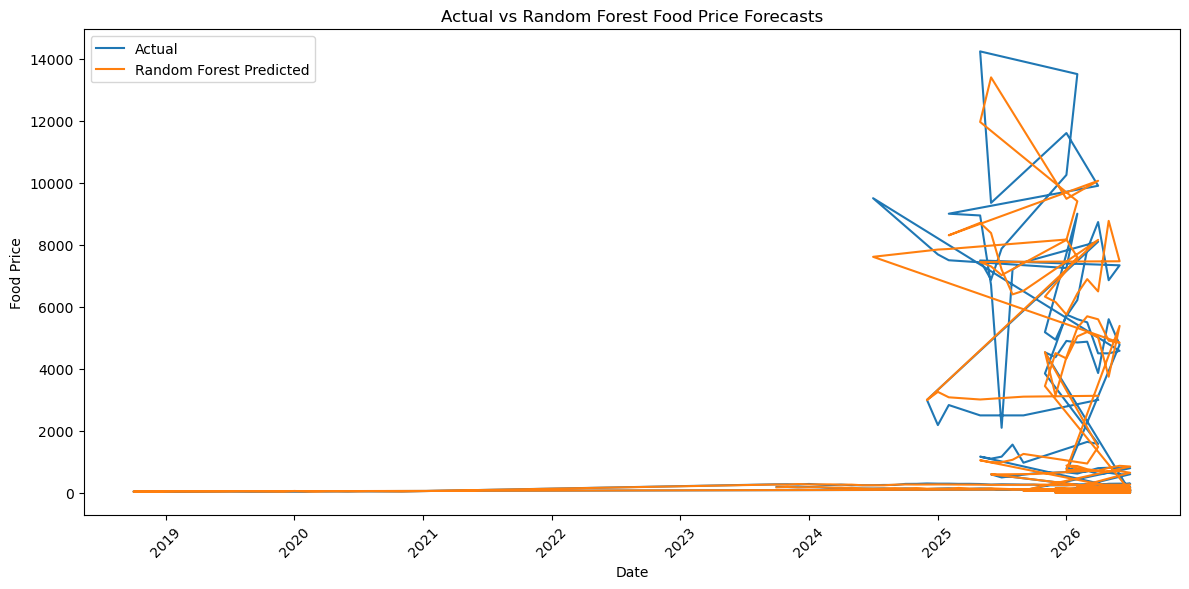

In [96]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test["date"],
    final_rf_test_pred,
    label="Random Forest Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Price")
plt.title("Actual vs Random Forest Food Price Forecasts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [97]:
model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "food_price_forecast.joblib"

joblib.dump(
    final_rf_pipeline,
    model_path
)

print("Model saved to:", model_path)

Model saved to: ..\data\models\food_price_forecast.joblib


In [98]:
metadata = {
    "model": "RandomForestRegressor",
    "model_version": "1.0",
    "target": target,
    "features": features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "training_rows": len(train_validation),
    "test_rows": len(test),
    "test_mae": 226.982710,
    "test_rmse": 670.976313,
    "test_r2": 0.941782,
    "test_mape": 11.985635,
    "hyperparameters": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1,
        "random_state": 42
    }
}

metadata_path = model_dir / "food_price_forecast_metadata.json"

with open(metadata_path, "w") as file:
    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved to:", metadata_path)

Metadata saved to: ..\data\models\food_price_forecast_metadata.json


In [99]:
loaded_model = joblib.load(
    "../data/models/food_price_forecast.joblib"
)

loaded_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

loaded_prediction

array([179.35439515, 193.25653968, 179.87762853, 181.60400614,
       188.75122056])

# INFLATION

## 1. Load & sanity-check the data

In [158]:
df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\capstone\EconIQ\data\raw\macro_inflation_forecast.csv")

In [159]:
df.head()

,date,inflation_12m,inflation_lag_1,inflation_lag_3,inflation_lag_6,inflation_lag_12,cbr,tbill_91,tbill_182,interbank,lending,deposit,savings,target_inflation_next_month
0,2006-06-01,4.28,4.47,8.85,4.70,11.92,9.75,6.60,7.32,6.41,13.79,4.35,1.27,4.16
1,2006-07-01,4.16,4.28,5.44,8.39,11.76,9.75,5.89,6.42,5.74,13.72,4.31,1.32,4.92
2,2006-08-01,4.92,4.16,4.47,9.39,6.87,10.00,5.96,6.47,5.66,13.64,4.08,1.41,5.93
3,2006-09-01,5.93,4.92,4.28,8.85,4.27,10.00,6.45,7.45,6.02,13.54,4.04,1.36,6.55
4,2006-10-01,6.55,5.93,4.16,5.44,3.72,10.00,6.83,8.31,6.08,14.01,4.11,1.35,6.64


In [160]:
print(df.shape)
print(df.columns)
df.info()

(241, 14)
Index(['date', 'inflation_12m', 'inflation_lag_1', 'inflation_lag_3',
       'inflation_lag_6', 'inflation_lag_12', 'cbr', 'tbill_91', 'tbill_182',
       'interbank', 'lending', 'deposit', 'savings',
       'target_inflation_next_month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         241 non-null    object 
 1   inflation_12m                241 non-null    float64
 2   inflation_lag_1              241 non-null    float64
 3   inflation_lag_3              241 non-null    float64
 4   inflation_lag_6              241 non-null    float64
 5   inflation_lag_12             241 non-null    float64
 6   cbr                          241 non-null    float64
 7   tbill_91                     241 non-null    float64
 8   tbill_182                    241 non-n

In [ ]:
# Check for duplicates 
df.duplicated().sum()   

np.int64(0)

In [ ]:
#Check for missing values 
df.isna().sum()    

date                           0
inflation_12m                  0
inflation_lag_1                0
inflation_lag_3                0
inflation_lag_6                0
inflation_lag_12               0
cbr                            0
tbill_91                       0
tbill_182                      0
interbank                      0
lending                        0
deposit                        0
savings                        0
target_inflation_next_month    0
dtype: int64

In [163]:
df['date'] = pd.to_datetime(df['date'])

In [164]:
# Set date as index for time-series steps (keep a copy with it as a column too)
df = df.set_index('date')
df.index.freq = None 
monthly_check = df.asfreq('MS')

## 2. Univariate EDA

For each variable: what's the central tendency, spread, skew, and are there extreme outliers? 


In [165]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
inflation_12m,241.0,7.082739,3.802978,1.85,4.58,6.08,7.74,19.72
inflation_lag_1,241.0,7.074689,3.806460,1.85,4.56,6.03,7.74,19.72
inflation_lag_3,241.0,7.083071,3.808346,1.85,4.56,6.03,7.76,19.72
inflation_lag_6,241.0,7.122241,3.802796,1.85,4.63,6.09,7.88,19.72
inflation_lag_12,241.0,7.189336,3.818120,1.85,4.73,6.26,7.91,19.72
cbr,241.0,9.331950,2.376595,5.75,8.25,9.00,10.00,18.00
tbill_91,241.0,8.601394,3.192848,1.60,7.10,8.01,9.16,21.65
tbill_182,241.0,9.457780,3.168645,1.72,7.91,8.91,10.40,21.52
interbank,241.0,7.249149,4.118398,0.98,4.70,6.52,8.88,28.90
lending,241.0,14.655851,2.102836,11.89,13.14,14.03,16.00,20.34


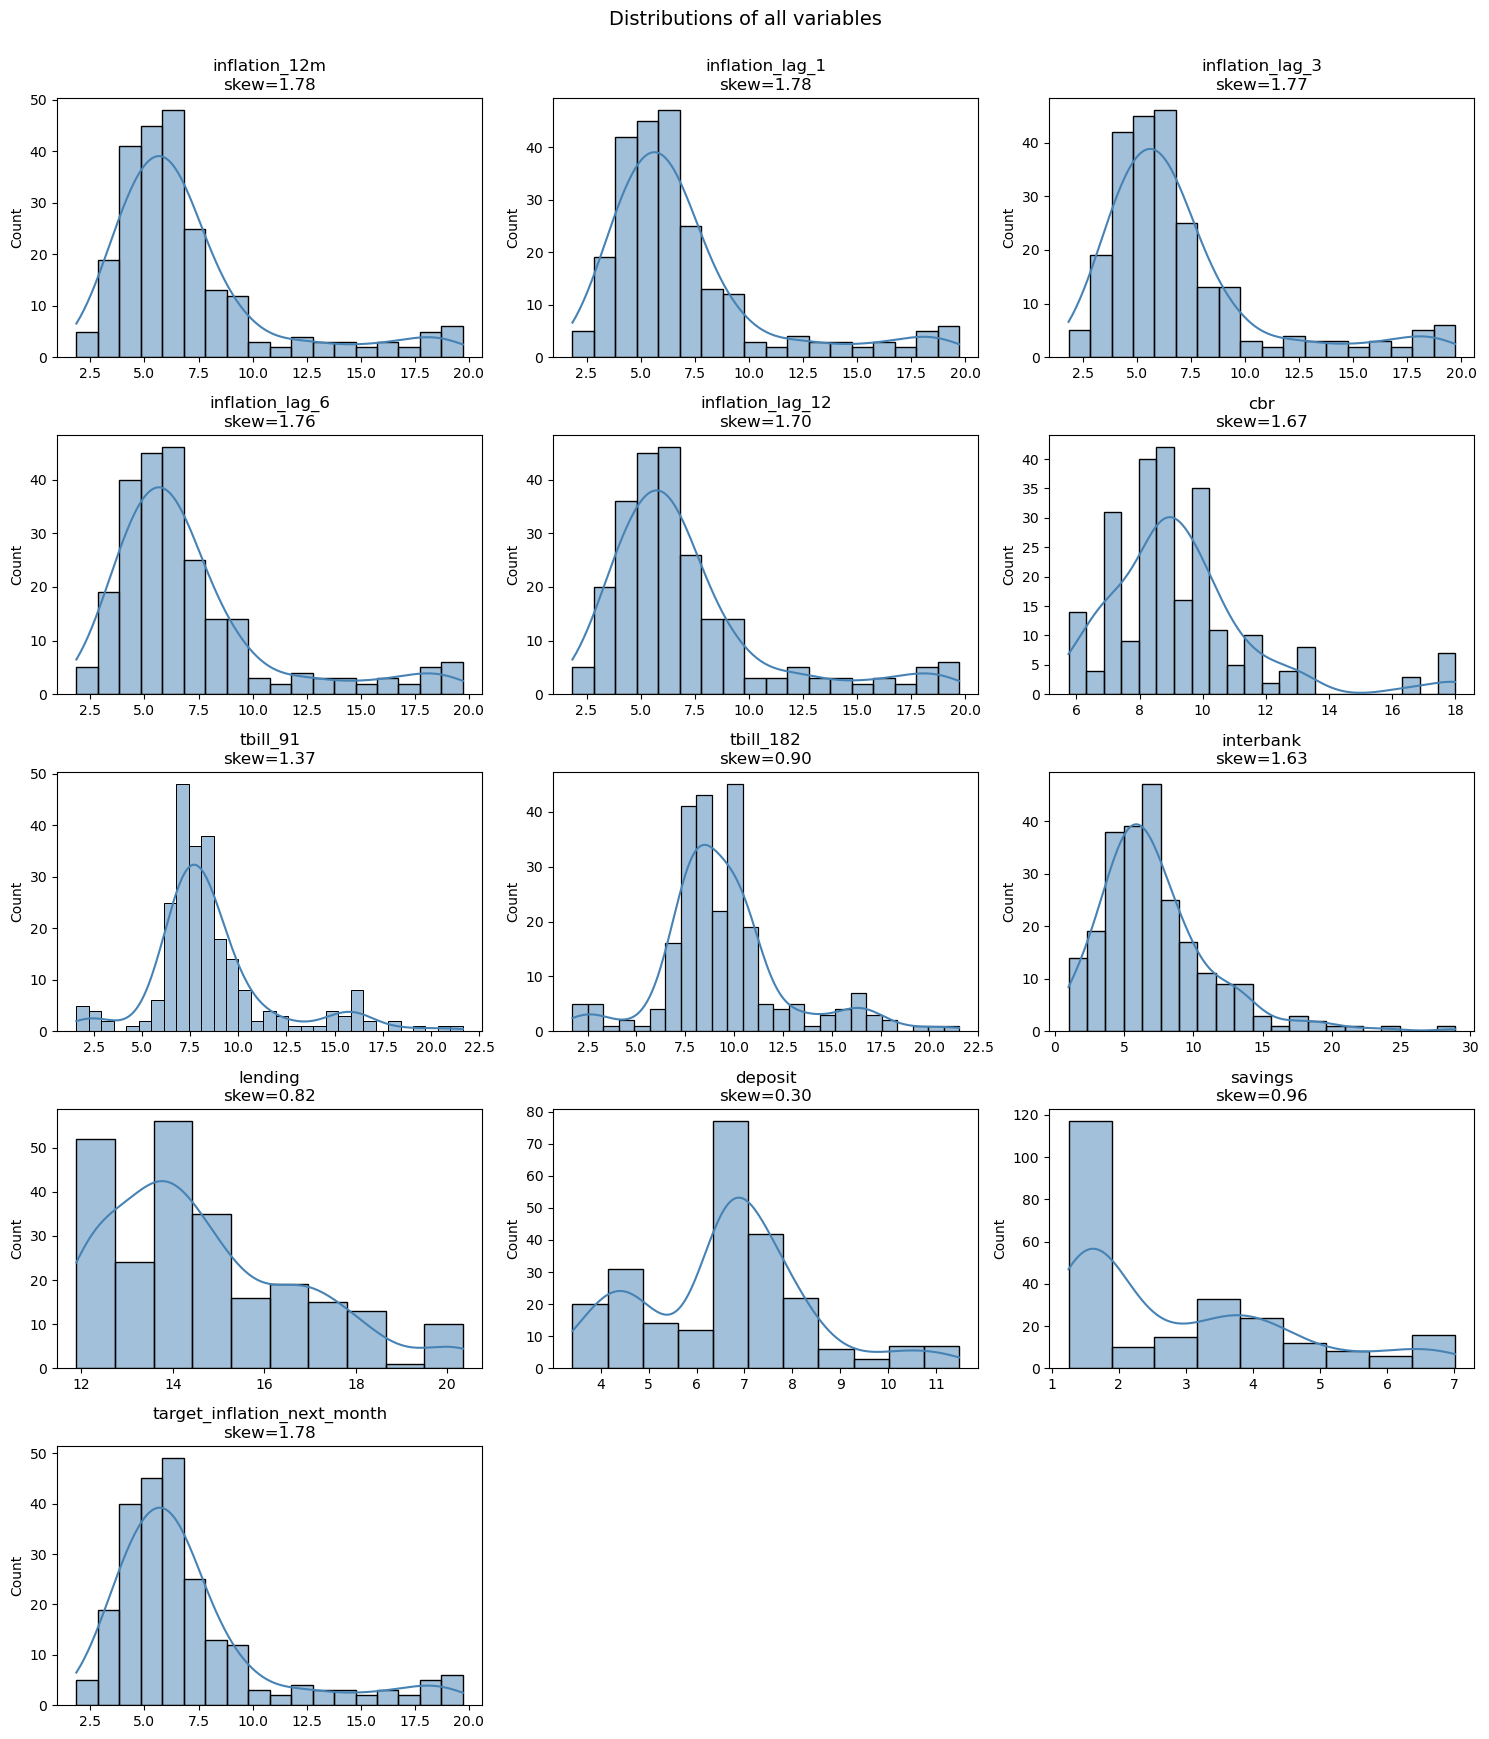

In [166]:
#SKEWNESS
fig, axes = plt.subplots(5, 3, figsize=(15, 17))
axes = axes.flatten()
numeric_cols = df.columns.tolist()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}')
    ax.set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distributions of all variables', y=1.02, fontsize=14)
plt.show()


Most of the inflation/lag variables and `cbr`/T-bill rates show right-skew 

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12704\3725372061.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


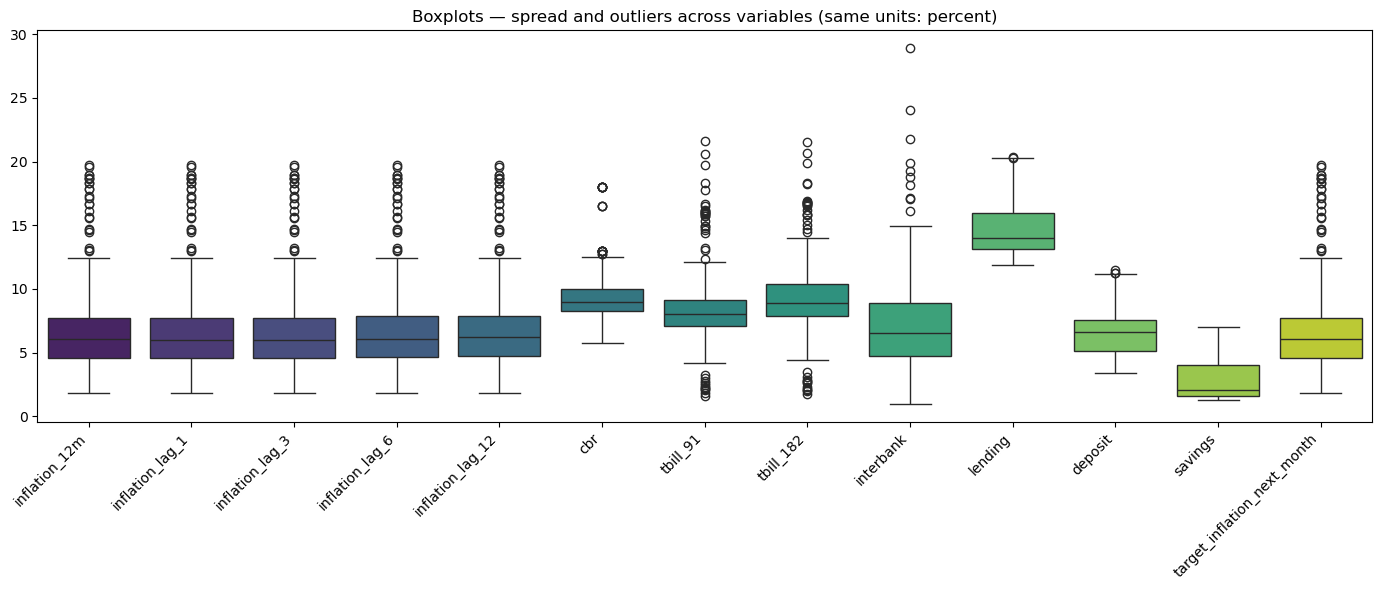

In [167]:
# OUTLIERS
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, ax=ax, palette='viridis')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Boxplots — spread and outliers across variables (same units: percent)')
plt.tight_layout()
plt.show()

## 3. Time-series EDA

In this section we look at:
- The raw trend of inflation and the target over time (are there regimes/spikes?)
- Whether the policy-rate variables move together with inflation (as monetary theory would predict)
- Rolling statistics, to see if the mean/variance is stable over time

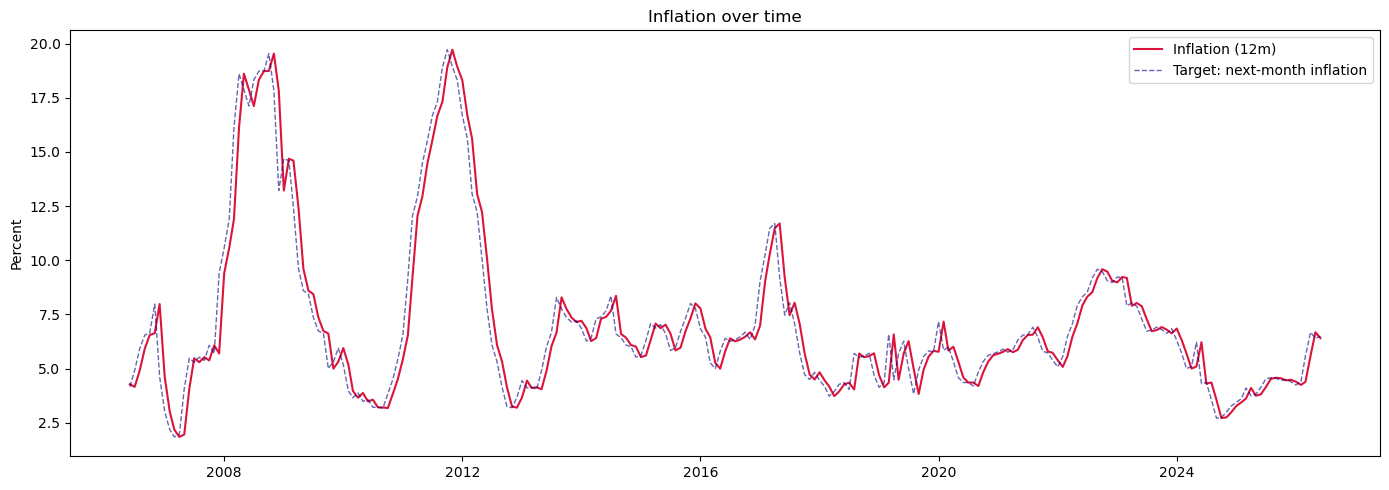

In [168]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['inflation_12m'], label='Inflation (12m)', color='crimson', linewidth=1.5)
ax.plot(df.index, df['target_inflation_next_month'], label='Target: next-month inflation', color='navy',
        linewidth=1, alpha=0.6, linestyle='--')
ax.set_title('Inflation over time')
ax.set_ylabel('Percent')
ax.legend()
plt.tight_layout()
plt.show()

Two clear regimes jump out: a sharp spike around 2008 (global financial crisis / food-fuel price shock) and
further elevated periods later in the sample. This immediately tells us the series is **not stationary** in the sense that the mean level shifts across time.

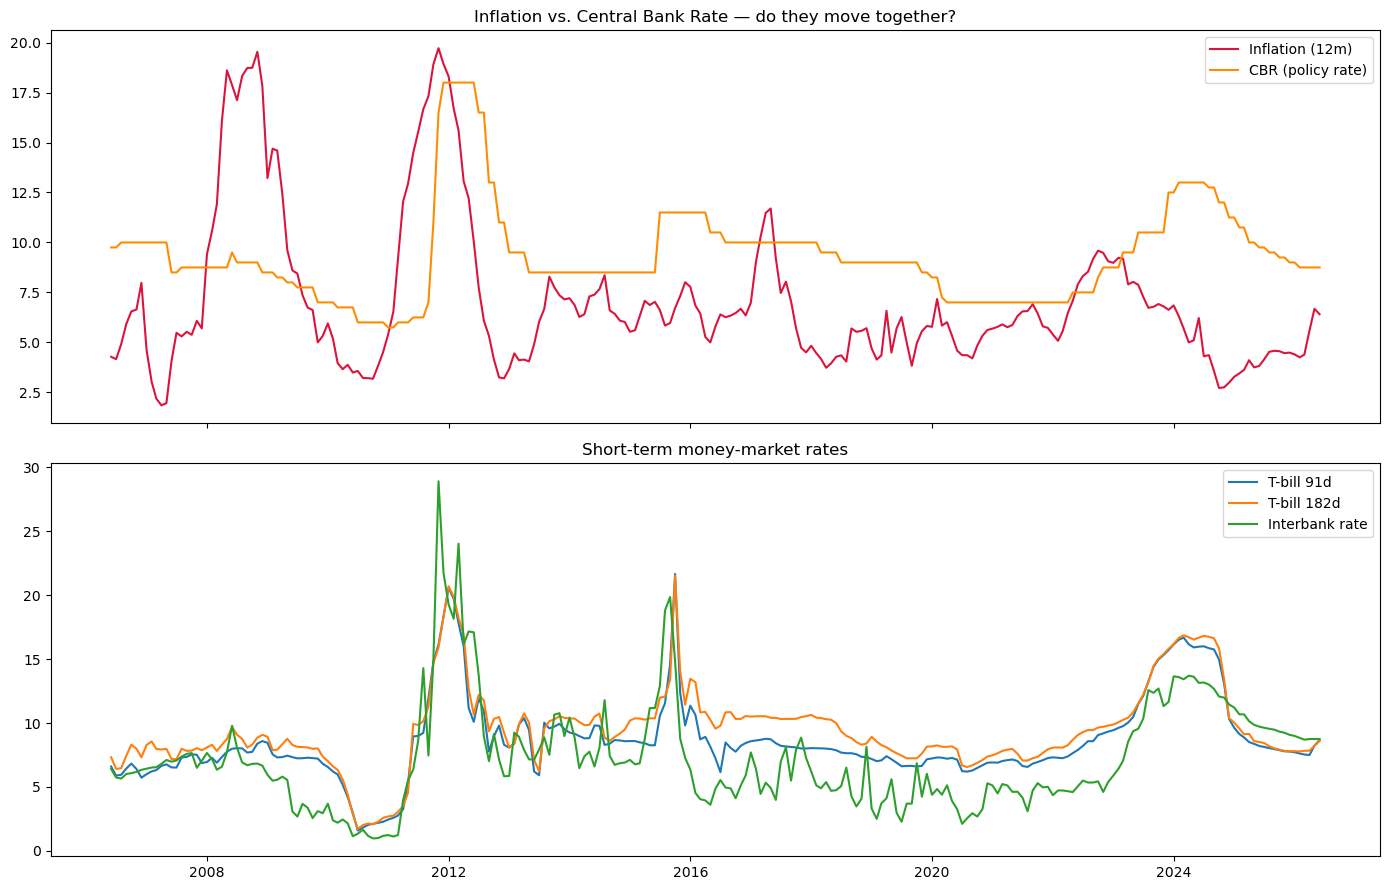

In [169]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df['inflation_12m'], color='crimson', label='Inflation (12m)')
axes[0].plot(df.index, df['cbr'], color='darkorange', label='CBR (policy rate)')
axes[0].set_title('Inflation vs. Central Bank Rate — do they move together?')
axes[0].legend()

axes[1].plot(df.index, df['tbill_91'], label='T-bill 91d')
axes[1].plot(df.index, df['tbill_182'], label='T-bill 182d')
axes[1].plot(df.index, df['interbank'], label='Interbank rate')
axes[1].set_title('Short-term money-market rates')
axes[1].legend()

plt.tight_layout()
plt.show()

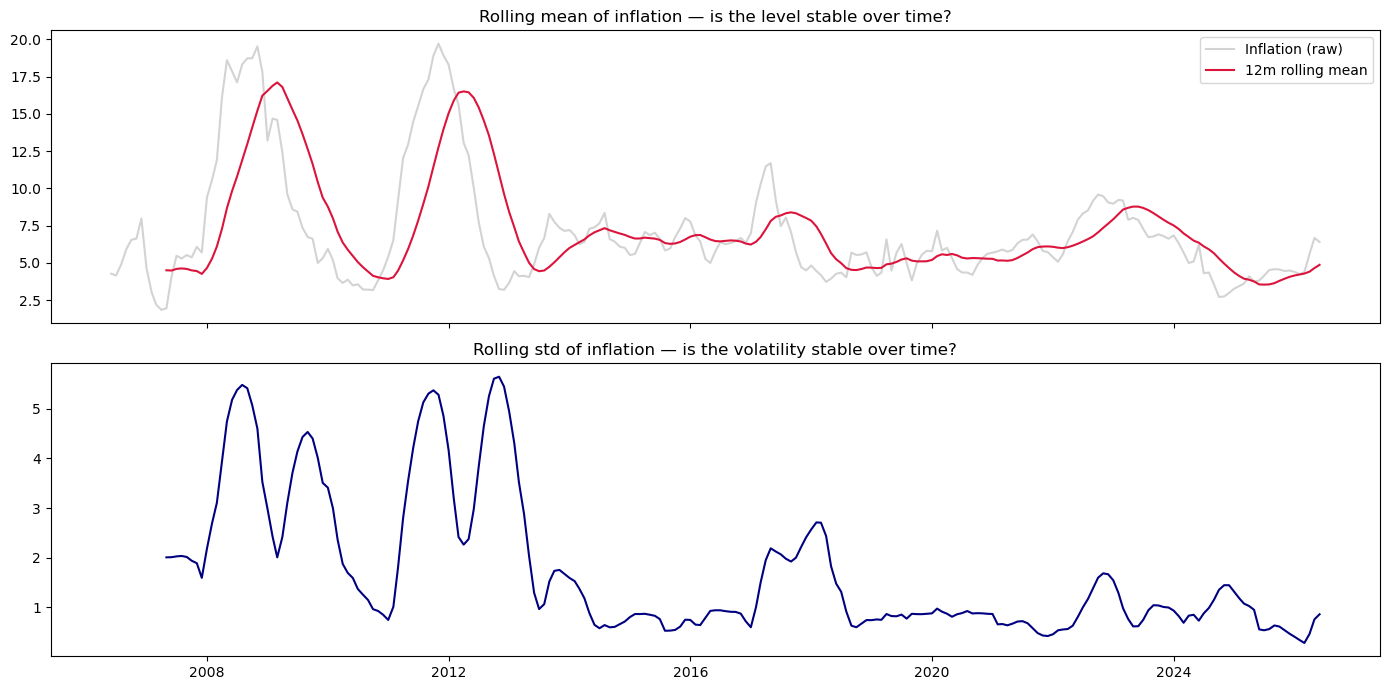

In [170]:
roll_window = 12  # 12-month rolling window, matching the inflation series' own 12-month construction
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df.index, df['inflation_12m'], color='lightgray', label='Inflation (raw)')
axes[0].plot(df.index, df['inflation_12m'].rolling(roll_window).mean(), color='crimson', label=f'{roll_window}m rolling mean')
axes[0].set_title('Rolling mean of inflation — is the level stable over time?')
axes[0].legend()

axes[1].plot(df.index, df['inflation_12m'].rolling(roll_window).std(), color='navy')
axes[1].set_title('Rolling std of inflation — is the volatility stable over time?')

plt.tight_layout()
plt.show()

Both the rolling mean and rolling standard deviation clearly drift over time rather than sitting flat visual
evidence against stationarity.

## 4. Bivariate EDA: correlations & multicollinearity

1. Which variables correlate most with the target?
2. How correlated are the *predictors* with each other? 


In [171]:
#understanding target variable
df['target_inflation_next_month'].describe()

count    241.000000
mean       7.091909
std        3.798854
min        1.850000
25%        4.590000
50%        6.090000
75%        7.740000
max       19.720000
Name: target_inflation_next_month, dtype: float64

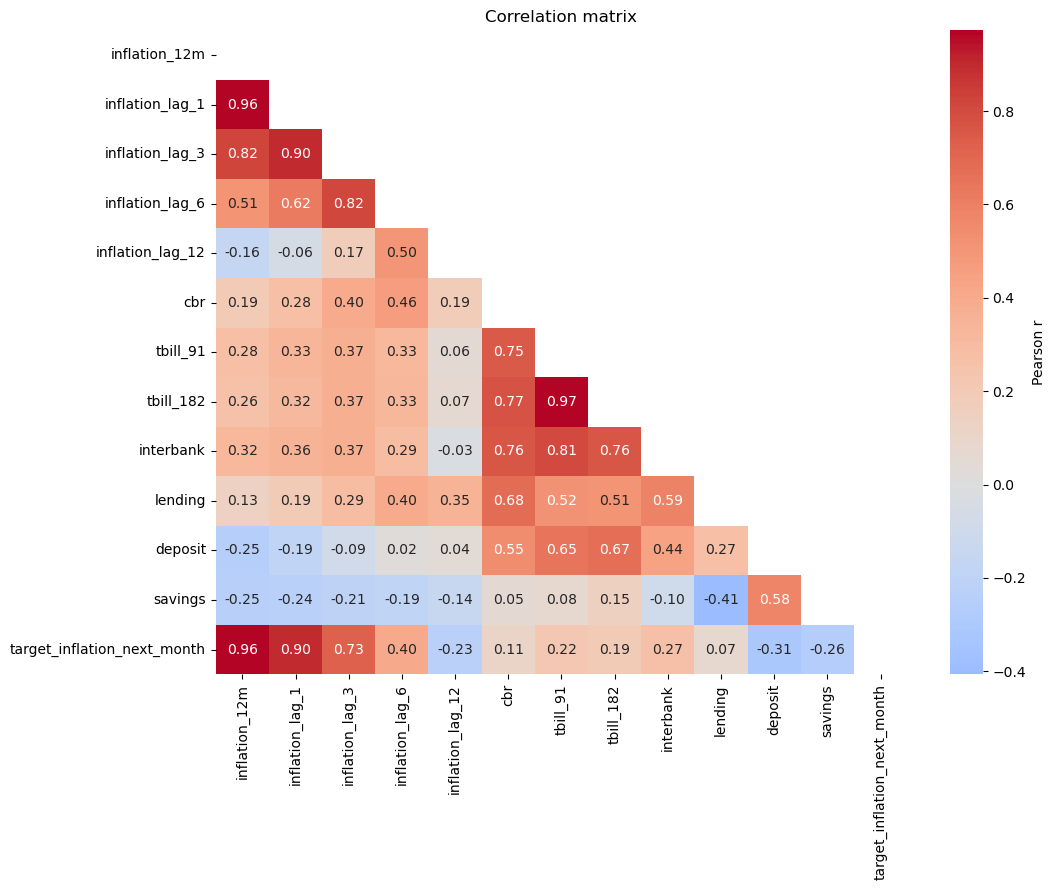

In [172]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

In [173]:
target_corr = corr['target_inflation_next_month'].drop('target_inflation_next_month').sort_values(key=abs, ascending=False)
target_corr

inflation_12m       0.963075
inflation_lag_1     0.900115
inflation_lag_3     0.727601
inflation_lag_6     0.404844
deposit            -0.310924
interbank           0.269664
savings            -0.256253
inflation_lag_12   -0.230634
tbill_91            0.220761
tbill_182           0.194586
cbr                 0.105795
lending             0.073041
Name: target_inflation_next_month, dtype: float64

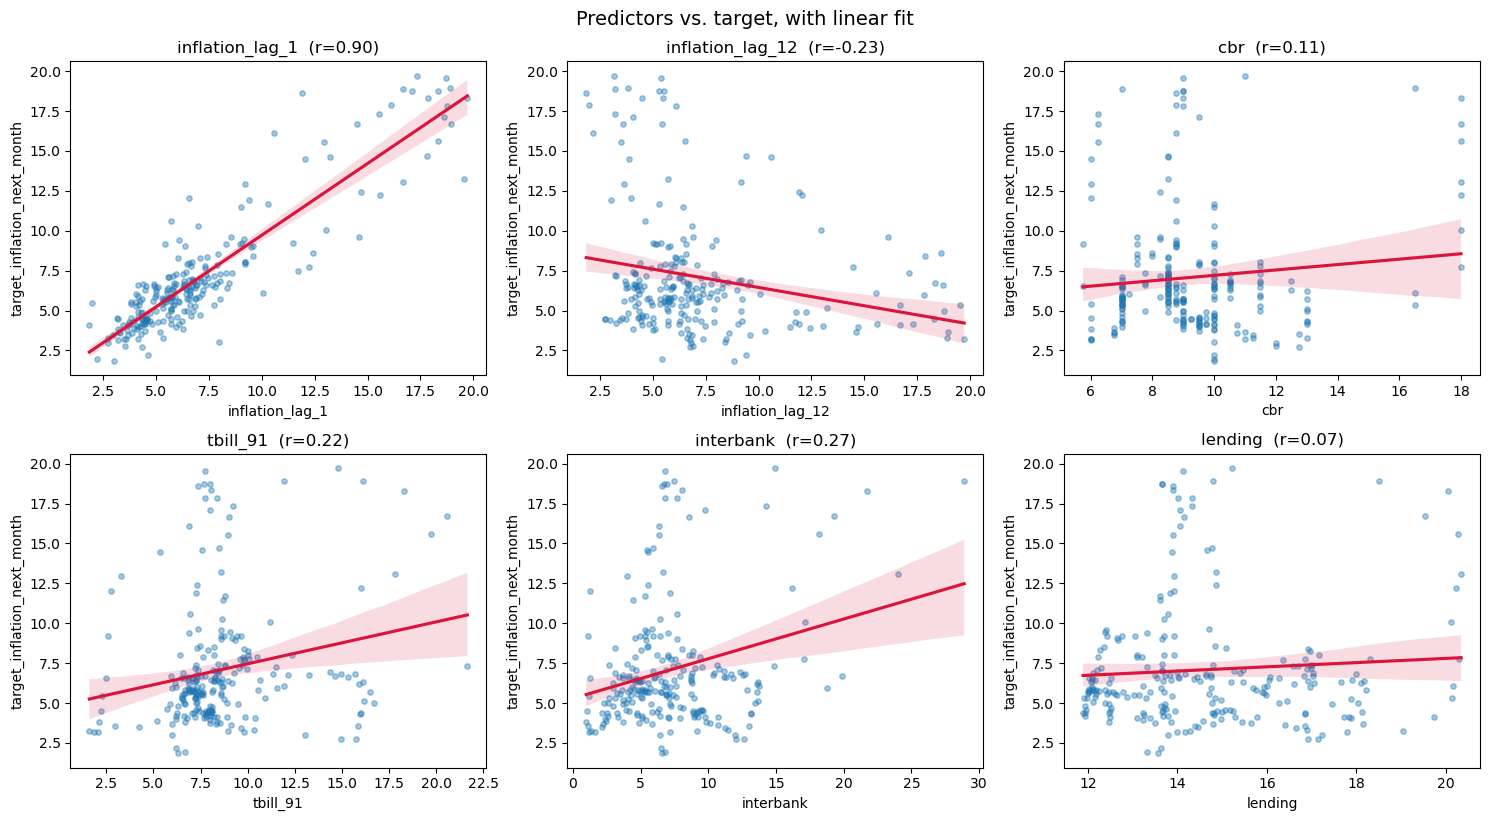

In [174]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
predictors_to_plot = ['inflation_lag_1', 'inflation_lag_12', 'cbr', 'tbill_91', 'interbank', 'lending']

for ax, col in zip(axes, predictors_to_plot):
    sns.regplot(x=df[col], y=df['target_inflation_next_month'], ax=ax,
                scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'crimson'})
    r = df[col].corr(df['target_inflation_next_month'])
    ax.set_title(f'{col}  (r={r:.2f})')

plt.tight_layout()
plt.suptitle('Predictors vs. target, with linear fit', y=1.02, fontsize=14)
plt.show()

## 5. Statistical analysis I: stationarity & autocorrelation

Two formal, standard time-series tests before any regression:

- **Augmented Dickey-Fuller (ADF) test** - null hypothesis: the series has a unit root (is non-stationary).
- **ACF / PACF plots** - show how correlated the series is with its own past, and at what lags

In [175]:
from statsmodels.tsa.stattools import adfuller
level = adfuller(df['inflation_12m'].dropna())

print("ADF Test: Level")
print("ADF statistic:", level[0])
print("p-value:", level[1])
print("Critical values:", level[4])

# First difference
diff = adfuller(df['inflation_12m'].diff().dropna())

print("\nADF Test: First Difference")
print("ADF statistic:", diff[0])
print("p-value:", diff[1])
print("Critical values:", diff[4])

ADF Test: Level
ADF statistic: -3.29134654369403
p-value: 0.015269743270412977
Critical values: {'1%': np.float64(-3.4597521044060353), '5%': np.float64(-2.874472927517147), '10%': np.float64(-2.5736628197530864)}

ADF Test: First Difference
ADF statistic: -7.191679973629492
p-value: 2.49424030652762e-10
Critical values: {'1%': np.float64(-3.4593607492757554), '5%': np.float64(-2.8743015807562924), '10%': np.float64(-2.5735714042782396)}


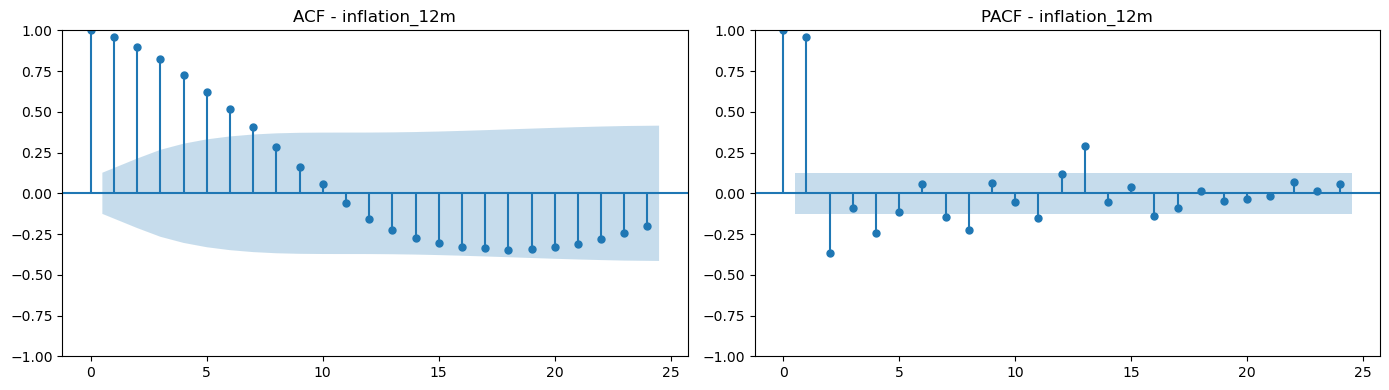

In [176]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['inflation_12m'].dropna(), lags=24, ax=axes[0])
axes[0].set_title('ACF - inflation_12m')
plot_pacf(df['inflation_12m'].dropna(), lags=24, ax=axes[1], method='ywm')
axes[1].set_title('PACF - inflation_12m')
plt.tight_layout()
plt.show()

## Modeling

In [ ]:
#feature engineering
rows_before = len(df)

# Target: change in inflation 
df["target_change"] = df["target_inflation_next_month"] - df["inflation_12m"]

# Base features 
feature_cols = [
    "inflation_lag_1", "inflation_lag_3", "inflation_lag_6", "inflation_lag_12",
    "cbr", "tbill_91", "tbill_182", "interbank", "lending", "deposit", "savings",
]

#  Rate-of-change features
for col in ["cbr", "tbill_91", "tbill_182", "interbank"]:
    df[f"{col}_chg_1m"] = df[col].diff()
    feature_cols.append(f"{col}_chg_1m")

# Rolling means of inflation 
df["inflation_roll_3"] = df["inflation_12m"].rolling(3).mean()
df["inflation_roll_6"] = df["inflation_12m"].rolling(6).mean()
feature_cols += ["inflation_roll_3", "inflation_roll_6"]

#Policy-stance spread features 
df["spread_tbill_cbr"] = df["tbill_91"] - df["cbr"]
df["spread_credit"]    = df["lending"] - df["deposit"]
feature_cols += ["spread_tbill_cbr", "spread_credit"]

#  Seasonality (month of year, cyclical encoding) 
df = df.reset_index()   # brings 'date' back as a column
month = pd.to_datetime(df["date"]).dt.month
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

feature_cols += ["month_sin", "month_cos"]

# Drop rows where any feature or the target is NaN (rolling/diff warm-up)
df = df.dropna(subset=feature_cols + ["target_change"]).reset_index(drop=True)

print(f"Rows before feature engineering: {rows_before}")
print(f"Rows after  feature engineering: {len(df)}  (lost {rows_before - len(df)} to warm-up)")
print(f"Number of features: {len(feature_cols)}")


Rows before feature engineering: 241
Rows after  feature engineering: 236  (lost 5 to warm-up)
Number of features: 21


## Chronological train / validation / test split

In [181]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train      = df.iloc[:train_end]
validation = df.iloc[train_end:val_end]
test       = df.iloc[val_end:]

print(f"Train: {len(train):3d} rows  ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Val:   {len(validation):3d} rows  ({validation['date'].min().date()} -> {validation['date'].max().date()})")
print(f"Test:  {len(test):3d} rows  ({test['date'].min().date()} -> {test['date'].max().date()})")

X_train, y_train = train[feature_cols],      train["target_change"]
X_val,   y_val   = validation[feature_cols], validation["target_change"]
X_test,  y_test  = test[feature_cols],       test["target_change"]

# Level targets (for final metrics)
y_train_level = train["target_inflation_next_month"]
y_val_level   = validation["target_inflation_next_month"]
y_test_level  = test["target_inflation_next_month"]

# Naive baseline predictions 
naive_train_pred = train["inflation_12m"].values
naive_val_pred   = validation["inflation_12m"].values
naive_test_pred  = test["inflation_12m"].values


def to_level(change_pred, base_series):
    """Convert a predicted change back into an absolute inflation level."""
    return np.asarray(base_series) + np.asarray(change_pred)

Train: 165 rows  (2006-11-01 -> 2020-07-01)
Val:    35 rows  (2020-08-01 -> 2023-06-01)
Test:   36 rows  (2023-07-01 -> 2026-06-01)


##  Evaluation 

In [182]:
def evaluate(y_true, y_pred, label, store=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{label:32s} MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:>7.4f}  MAPE={mape:6.2f}%")
    row = {"model": label, "mae": float(mae), "rmse": float(rmse),
           "r2": float(r2), "mape": float(mape)}
    if store is not None:
        store.append(row)
    return row

val_results  = []
test_results = []

##  Baseline — Naive

In [183]:
evaluate(y_val_level,  naive_val_pred,  "Naive (baseline)", store=val_results)
evaluate(y_test_level, naive_test_pred, "Naive (baseline)", store=test_results)

Naive (baseline)                 MAE=0.3589  RMSE=0.4562  R2= 0.9094  MAPE=  5.34%
Naive (baseline)                 MAE=0.3797  RMSE=0.5635  R2= 0.8138  MAPE=  8.17%


{'model': 'Naive (baseline)',
 'mae': 0.37972222222222224,
 'rmse': 0.56347877806829,
 'r2': 0.8138005182027072,
 'mape': 8.173005931930483}

## Ridge regression 

In [194]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import random




In [188]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge()),
])

ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={"ridge__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
print("Best Ridge alpha:", ridge_grid.best_params_)

ridge_val_level  = to_level(best_ridge.predict(X_val),  validation["inflation_12m"])
ridge_test_level = to_level(best_ridge.predict(X_test), test["inflation_12m"])

evaluate(y_val_level,  ridge_val_level,  "Ridge ", store=val_results)
evaluate(y_test_level, ridge_test_level, "Ridge ", store=test_results)

Best Ridge alpha: {'ridge__alpha': 500.0}
Ridge                            MAE=0.3271  RMSE=0.4167  R2= 0.9244  MAPE=  4.99%
Ridge                            MAE=0.3922  RMSE=0.5214  R2= 0.8406  MAPE=  8.50%


{'model': 'Ridge ',
 'mae': 0.3921923255584899,
 'rmse': 0.5214075872361761,
 'r2': 0.8405670680878283,
 'mape': 8.500374618146516}

## XGBoost (tuned with TimeSeriesSplit)

In [196]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_param_grid = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.7, 0.9, 1.0],
}

xgb_search = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)

xgb_val_level  = to_level(best_xgb.predict(X_val),  validation["inflation_12m"])
xgb_test_level = to_level(best_xgb.predict(X_test), test["inflation_12m"])

evaluate(y_val_level,  xgb_val_level,  "XGBoost ", store=val_results)
evaluate(y_test_level, xgb_test_level, "XGBoost ", store=test_results)

Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.9}
XGBoost                          MAE=0.3309  RMSE=0.4268  R2= 0.9207  MAPE=  4.89%
XGBoost                          MAE=0.3822  RMSE=0.5598  R2= 0.8162  MAPE=  8.24%


{'model': 'XGBoost ',
 'mae': 0.38222938266893225,
 'rmse': 0.5597696357219586,
 'r2': 0.8162437949077138,
 'mape': 8.241363426829196}

## SARIMAX — classical benchmark

In [208]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [209]:
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

sarimax_features = ["cbr", "tbill_91", "interbank"]
orders_to_try = list(itertools.product([0, 1, 2], [0, 1], [0, 1, 2]))

best_sarimax, best_aic, best_order = None, np.inf, None

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for order in orders_to_try:
        try:
            cand = SARIMAX(
                train["target_inflation_next_month"],
                exog=train[sarimax_features],
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            if cand.aic < best_aic:
                best_aic, best_sarimax, best_order = cand.aic, cand, order
        except Exception as e:
            print("Failed:", order, "->", e)
            continue

print("Best SARIMAX order:", best_order, " AIC:", round(best_aic, 3))

# Validation forecast
sarimax_val_pred = best_sarimax.get_forecast(
    steps=len(validation),
    exog=validation[sarimax_features],
).predicted_mean.values

# Refit on train+validation, then forecast test horizon
sarimax_full = SARIMAX(
    pd.concat([train, validation])["target_inflation_next_month"],
    exog=pd.concat([train, validation])[sarimax_features],
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarimax_test_pred = sarimax_full.get_forecast(
    steps=len(test),
    exog=test[sarimax_features],
).predicted_mean.values

evaluate(y_val_level,  sarimax_val_pred,  "SARIMAX (tuned order)", store=val_results)
evaluate(y_test_level, sarimax_test_pred, "SARIMAX (tuned order)", store=test_results)

Best SARIMAX order: (1, 1, 2)  AIC: 489.946
SARIMAX (tuned order)            MAE=3.0534  RMSE=3.4313  R2=-4.1260  MAPE= 40.97%
SARIMAX (tuned order)            MAE=1.6218  RMSE=1.9948  R2=-1.3336  MAPE= 42.56%


{'model': 'SARIMAX (tuned order)',
 'mae': 1.6217541408308334,
 'rmse': 1.9948174864712591,
 'r2': -1.3336174994382852,
 'mape': 42.55674322220913}

## Model selection on the validation set

In [210]:
val_df = pd.DataFrame(val_results).sort_values("mae").reset_index(drop=True)
print("Validation comparison:")
print(val_df.to_string(index=False))

best_model_name = val_df.iloc[0]["model"]
print(f"\n-> Selected model on validation: {best_model_name}")

Validation comparison:
                   model      mae     rmse        r2      mape
                  Ridge  0.327131 0.416704  0.924402  4.986992
                XGBoost  0.330876 0.426813  0.920689  4.891403
Naive/XGB blend (w=0.00) 0.330876 0.426813  0.920689  4.891403
        Naive (baseline) 0.358857 0.456239  0.909376  5.337590
   SARIMAX (tuned order) 3.053408 3.431322 -4.126004 40.970433

-> Selected model on validation: Ridge 


## Naive / XGBoost blend

In [198]:
best_weight, best_val_mae = None, np.inf
for w in np.linspace(0, 1, 21):
    blend_val = w * naive_val_pred + (1 - w) * xgb_val_level
    m = mean_absolute_error(y_val_level, blend_val)
    if m < best_val_mae:
        best_val_mae, best_weight = m, w

print(f"Best blend weight on naive (chosen on validation): {best_weight:.2f}")

blend_val_pred  = best_weight * naive_val_pred  + (1 - best_weight) * xgb_val_level
blend_test_pred = best_weight * naive_test_pred + (1 - best_weight) * xgb_test_level

evaluate(y_val_level,  blend_val_pred,  f"Naive/XGB blend (w={best_weight:.2f})", store=val_results)
evaluate(y_test_level, blend_test_pred, f"Naive/XGB blend (w={best_weight:.2f})", store=test_results)

Best blend weight on naive (chosen on validation): 0.00
Naive/XGB blend (w=0.00)         MAE=0.3309  RMSE=0.4268  R2= 0.9207  MAPE=  4.89%
Naive/XGB blend (w=0.00)         MAE=0.3822  RMSE=0.5598  R2= 0.8162  MAPE=  8.24%


{'model': 'Naive/XGB blend (w=0.00)',
 'mae': 0.38222938266893225,
 'rmse': 0.5597696357219586,
 'r2': 0.8162437949077138,
 'mape': 8.241363426829196}

## Final test-set comparison


In [199]:
test_df = pd.DataFrame(test_results).sort_values("mae").reset_index(drop=True)
print("Final test-set comparison:")
print(test_df.to_string(index=False))


Final test-set comparison:
                   model      mae     rmse       r2     mape
        Naive (baseline) 0.379722 0.563479 0.813801 8.173006
                XGBoost  0.382229 0.559770 0.816244 8.241363
Naive/XGB blend (w=0.00) 0.382229 0.559770 0.816244 8.241363
                  Ridge  0.392192 0.521408 0.840567 8.500375


## Residual analysis

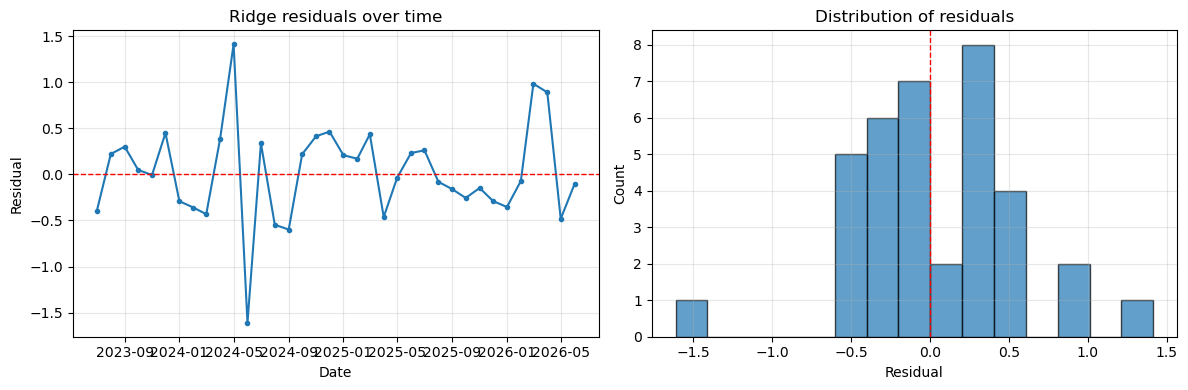

Residual mean: 0.0215   std: 0.5210


In [200]:
residuals = y_test_level.values - ridge_test_level

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(test["date"], residuals, marker="o", markersize=3)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Ridge residuals over time")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Residual")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=15, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}   std: {residuals.std():.4f}")

##  Forecast plot — actual vs. models 

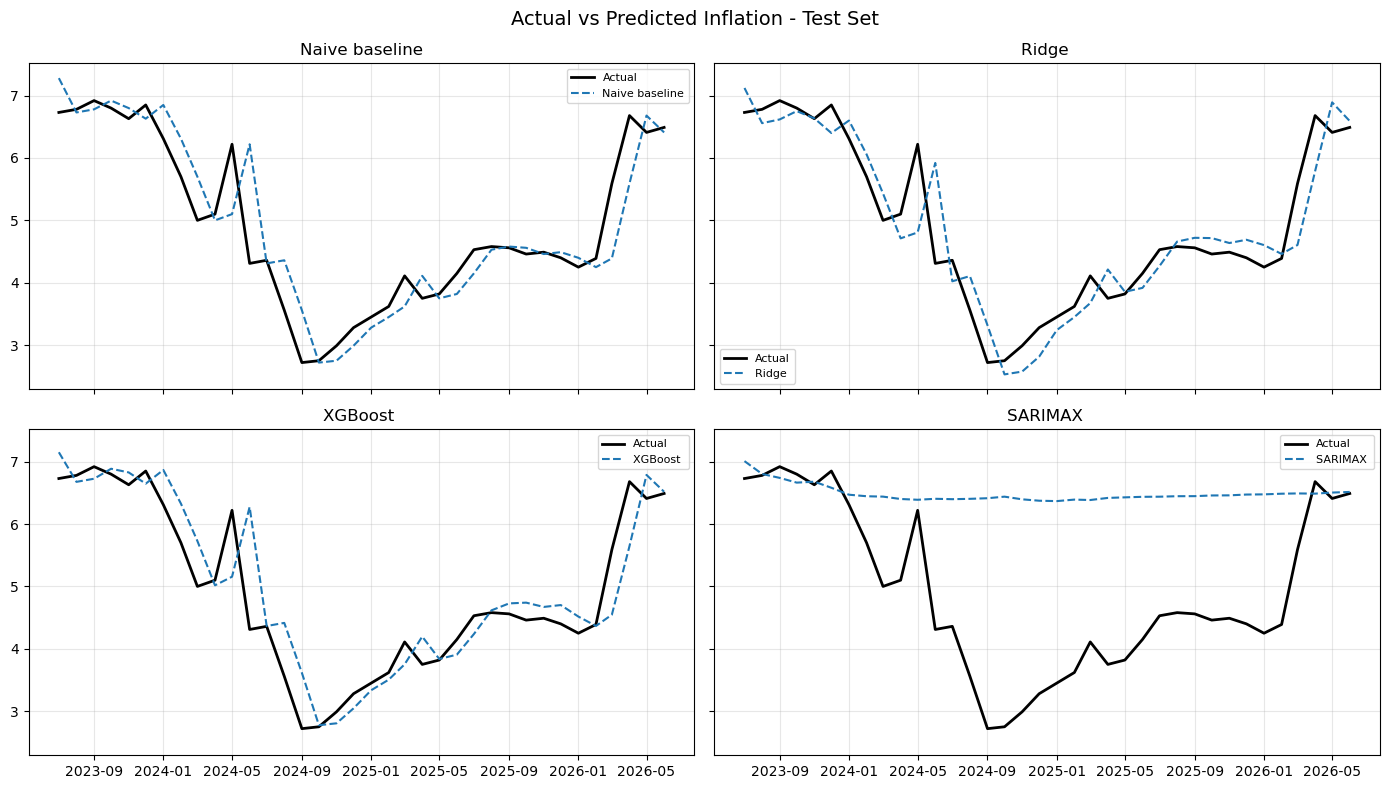

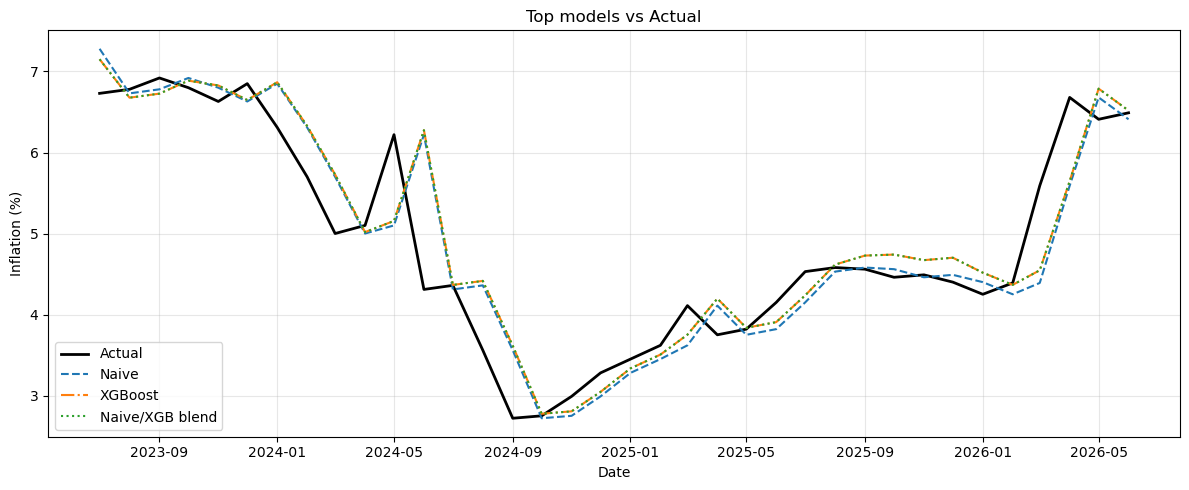

In [211]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
panels = [
    ("Naive baseline",            naive_test_pred),
    ("Ridge ",         ridge_test_level),
    ("XGBoost ",xgb_test_level),
    ("SARIMAX ",     sarimax_test_pred),
]
for ax, (label, pred) in zip(axes.ravel(), panels):
    ax.plot(test["date"], y_test_level, label="Actual", color="black", linewidth=2)
    ax.plot(test["date"], pred, label=label, linestyle="--")
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Actual vs Predicted Inflation - Test Set", fontsize=14)
plt.tight_layout()
plt.show()

# Focused comparison: top-3 on the same axes
plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test_level,   label="Actual",        color="black", linewidth=2)
plt.plot(test["date"], naive_test_pred,label="Naive",         linestyle="--")
plt.plot(test["date"], xgb_test_level, label="XGBoost",       linestyle="-.")
plt.plot(test["date"], blend_test_pred,label="Naive/XGB blend",linestyle=":")
plt.title("Top models vs Actual")
plt.xlabel("Date"); plt.ylabel("Inflation (%)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Save selected model 

In [212]:
import joblib
from pathlib import Path

model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_xgb,
    model_dir / "inflation_forecast_xgb.joblib"
)

joblib.dump(
    best_ridge,
    model_dir / "inflation_forecast_ridge.joblib"
)

joblib.dump(
    best_sarimax,
    model_dir / "inflation_forecast_sarimax.joblib"
)


print("Models saved to:", model_dir.resolve())


Models saved to: C:\Users\ADMIN\OneDrive\Desktop\capstone\EconIQ\data\models


## Recursive out-of-sample forecast: July 2026 -> December 2026

In [ ]:

FORECAST_HORIZON = 6
RATE_COLS = ["cbr", "tbill_91", "tbill_182", "interbank",
             "lending", "deposit", "savings"]

# Last observed row (June 2026)
last_row = df.iloc[-1].copy()
last_date = last_row["date"]

# History of inflation_12m 
infl_history = list(df["inflation_12m"].values)

held_rates = {c: last_row[c] for c in RATE_COLS}

held_rate_changes = {f"{c}_chg_1m": 0.0
                     for c in ["cbr", "tbill_91", "tbill_182", "interbank"]}

forecast_rows = []
for h in range(1, FORECAST_HORIZON + 1):
    forecast_date = (last_date + pd.DateOffset(months=h))

    row = {}
    row["inflation_lag_1"]  = infl_history[-1]
    row["inflation_lag_3"]  = infl_history[-3]
    row["inflation_lag_6"]  = infl_history[-6]
    row["inflation_lag_12"] = infl_history[-12]

    for c, v in held_rates.items():
        row[c] = v
    for c, v in held_rate_changes.items():
        row[c] = v

    row["inflation_roll_3"] = np.mean(infl_history[-3:])
    row["inflation_roll_6"] = np.mean(infl_history[-6:])

    # Spreads
    row["spread_tbill_cbr"] = held_rates["tbill_91"] - held_rates["cbr"]
    row["spread_credit"]    = held_rates["lending"] - held_rates["deposit"]

    # Seasonality
    row["month_sin"] = np.sin(2 * np.pi * forecast_date.month / 12)
    row["month_cos"] = np.cos(2 * np.pi * forecast_date.month / 12)

    X_row = pd.DataFrame([row])[feature_cols]          
    pred_change = float(best_ridge.predict(X_row)[0])
    pred_level  = infl_history[-1] + pred_change

    infl_history.append(pred_level)

    forecast_rows.append({
        "date": forecast_date,
        "predicted_inflation": pred_level,
        "predicted_change": pred_change,
        "base_inflation": infl_history[-2],
    })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df["date"] = forecast_df["date"].dt.to_period("M").dt.to_timestamp()
print(forecast_df.to_string(index=False))

      date  predicted_inflation  predicted_change  base_inflation
2026-07-01             6.556524          0.146524        6.410000
2026-08-01             6.676071          0.119547        6.556524
2026-09-01             6.790977          0.114906        6.676071
2026-10-01             6.882227          0.091250        6.790977
2026-11-01             6.958657          0.076431        6.882227
2026-12-01             7.045606          0.086948        6.958657


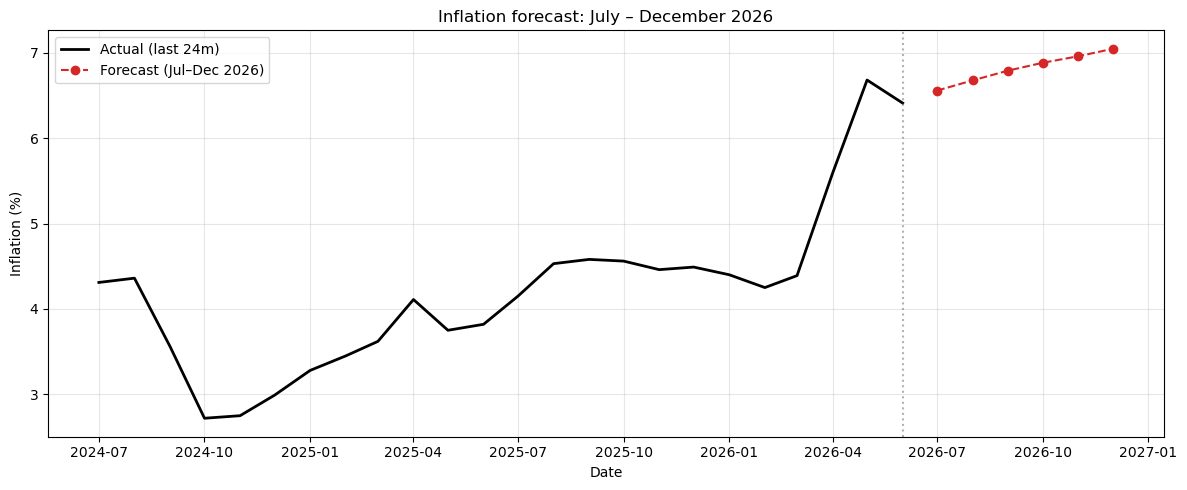

In [203]:
plt.figure(figsize=(12, 5))
# Show last 24 months of actual + 6 months of forecast
tail = df.tail(24)
plt.plot(tail["date"], tail["inflation_12m"], label="Actual (last 24m)",
         color="black", linewidth=2)
plt.plot(forecast_df["date"], forecast_df["predicted_inflation"],
         label="Forecast (Jul–Dec 2026)", color="tab:red",
         marker="o", linestyle="--")
plt.axvline(tail["date"].iloc[-1], color="grey", linestyle=":", alpha=0.6)
plt.title("Inflation forecast: July – December 2026")
plt.xlabel("Date"); plt.ylabel("Inflation (%)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()